# Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

# Reading

In [2]:
df = pd.read_csv("global_supply_chain_disruption_F.csv")

# Preprocessing

# Column Meaning Table

| Column                     | Meaning                              |
|--------------------------|--------------------------------------|
| Order_ID                 | har order ka unique ID               |
| Order_Date               | order kab place hua                  |
| Origin_City              | shipment kaha se start hua           |
| Destination_City         | shipment kaha ja raha hai            |
| Route_Type               | route type (domestic/international)  |
| Transportation_Mode      | transport ka type (road/air/sea)     |
| Product_Category         | product kis type ka hai              |
| Base_Lead_Time_Days      | ideal delivery time (no delay)       |
| Scheduled_Lead_Time_Days | planned delivery time                |
| Actual_Lead_Time_Days    | actual delivery time                 |
| Delay_Days               | kitne din delay hua                  |
| Delivery_Status          | on time ya delayed                   |
| Disruption_Event         | delay ka reason (weather etc.)       |
| Geopolitical_Risk_Index  | political risk level                 |
| Weather_Severity_Index   | weather kitna severe tha             |
| Inflation_Rate_Pct       | inflation rate us time               |
| Shipping_Cost_USD        | total shipping cost                  |
| Order_Weight_Kg          | shipment ka weight                   |
| Mitigation_Action_Taken  | delay handle karne ke liye action    |

In [3]:
df.columns

Index(['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City',
       'Route_Type', 'Transportation_Mode', 'Product_Category',
       'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days',
       'Actual_Lead_Time_Days', 'Delay_Days', 'Delivery_Status',
       'Disruption_Event', 'Geopolitical_Risk_Index', 'Weather_Severity_Index',
       'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg',
       'Mitigation_Action_Taken'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  object 
 1   Order_Date                10000 non-null  object 
 2   Origin_City               10000 non-null  object 
 3   Destination_City          10000 non-null  object 
 4   Route_Type                10000 non-null  object 
 5   Transportation_Mode       10000 non-null  object 
 6   Product_Category          10000 non-null  object 
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  object 
 12  Disruption_Event          1267 non-null   object 
 13  Geopolitical_Risk_Index   10000 non-null  float64
 14  Weather

In [5]:
df.head()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Auto Parts,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Auto Parts,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Auto Parts,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Auto Parts,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"New York, US","Hamburg, DE",Atlantic,Sea,Auto Parts,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping


In [6]:
df.tail()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
9995,ORD-525E3FA5,2024-10-14,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Auto Parts,7,8,8,0,On Time,NaN,0.58,8.1,3.38,7346.21,9299,Standard Shipping
9996,ORD-5E9DBD46,2024-09-10,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Auto Parts,7,10,7,0,On Time,NaN,0.37,5.5,2.34,4112.06,6003,Standard Shipping
9997,ORD-E6949429,2024-07-13,"Hamburg, DE","New York, US",Atlantic,Sea,Auto Parts,12,13,12,0,On Time,NaN,0.84,1.0,4.56,7346.20,7985,Standard Shipping
9998,ORD-29B9A2DA,2024-07-21,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Auto Parts,24,27,25,0,On Time,NaN,0.53,4.7,1.05,5810.94,7596,Standard Shipping
9999,ORD-DAEE9CDE,2025-09-02,"Hamburg, DE","New York, US",Atlantic,Sea,Auto Parts,12,14,12,0,On Time,NaN,0.78,3.3,5.17,5926.51,6659,Standard Shipping


In [7]:
df.sample(10)

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
7181,ORD-8A656629,2025-03-01,"Mumbai, IN","Felixstowe, UK",Suez,Air,Auto Parts,3,5,3,0,On Time,NaN,0.58,2.1,1.97,80764.86,9294,Standard Shipping
3200,ORD-19E21DA6,2024-04-12,"Shenzhen, CN","Rotterdam, NL",Suez,Sea,Auto Parts,28,30,29,0,On Time,NaN,0.85,6.1,4.32,2528.95,2734,Standard Shipping
8360,ORD-D273B874,2024-01-11,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Auto Parts,24,26,24,0,On Time,NaN,0.26,0.6,3.56,902.16,1432,Standard Shipping
6042,ORD-B0208ADA,2025-10-16,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Auto Parts,24,26,24,0,On Time,NaN,0.46,8.0,3.26,7086.84,9708,Standard Shipping
7030,ORD-82A672CB,2025-10-19,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Auto Parts,24,27,24,0,On Time,NaN,0.20,1.1,3.49,5953.80,9923,Standard Shipping
8433,ORD-44B54C7B,2024-03-29,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Auto Parts,7,8,7,0,On Time,NaN,0.19,8.4,5.81,4947.43,8315,Standard Shipping
1869,ORD-F2AAB0F1,2024-11-28,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Auto Parts,2,4,2,0,On Time,NaN,0.68,5.6,4.45,55680.24,6026,Standard Shipping
3785,ORD-9554D148,2024-02-25,"Santos, BR","Shanghai, CN",Commodity,Sea,Auto Parts,35,38,35,0,On Time,NaN,0.11,8.8,3.12,3205.13,5775,Standard Shipping
4731,ORD-620CFA5F,2024-12-18,"Shenzhen, CN","Rotterdam, NL",Suez,Sea,Auto Parts,28,30,41,11,Late,Geopolitical Conflict (Route Diversion),0.18,9.5,2.34,7560.50,8009,Re-routing
7037,ORD-4EF2964A,2024-04-28,"Santos, BR","Shanghai, CN",Commodity,Sea,Auto Parts,35,36,35,0,On Time,NaN,0.60,3.5,3.99,4204.00,5255,Standard Shipping


In [8]:
df.isna().sum()

Order_ID                       0
Order_Date                     0
Origin_City                    0
Destination_City               0
Route_Type                     0
Transportation_Mode            0
Product_Category               0
Base_Lead_Time_Days            0
Scheduled_Lead_Time_Days       0
Actual_Lead_Time_Days          0
Delay_Days                     0
Delivery_Status                0
Disruption_Event            8733
Geopolitical_Risk_Index        0
Weather_Severity_Index         0
Inflation_Rate_Pct             0
Shipping_Cost_USD              0
Order_Weight_Kg                0
Mitigation_Action_Taken        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500
std,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788
min,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000
25%,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000
50%,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000
75%,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000
max,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000


# EDA

In [11]:
# This is to see which plot will be best 
for col in df.columns:
    print(col, df[col].nunique())

Order_ID 10000
Order_Date 731
Origin_City 7
Destination_City 7
Route_Type 5
Transportation_Mode 2
Product_Category 1
Base_Lead_Time_Days 9
Scheduled_Lead_Time_Days 23
Actual_Lead_Time_Days 48
Delay_Days 21
Delivery_Status 2
Disruption_Event 3
Geopolitical_Risk_Index 81
Weather_Severity_Index 101
Inflation_Rate_Pct 679
Shipping_Cost_USD 9898
Order_Weight_Kg 6303
Mitigation_Action_Taken 3


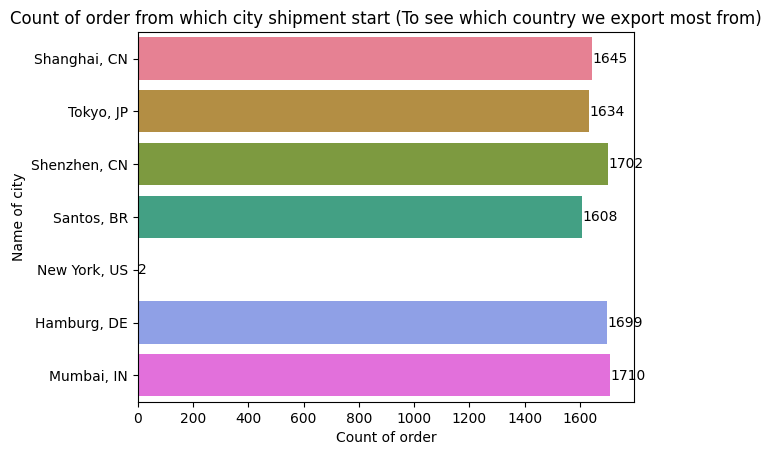

In [12]:
# Count of order from which city shipment start (To see which country we export most from)
ax = sns.countplot(y='Origin_City', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Count of order from which city shipment start (To see which country we export most from)")
plt.xlabel("Count of order")
plt.ylabel("Name of city")
plt.show()

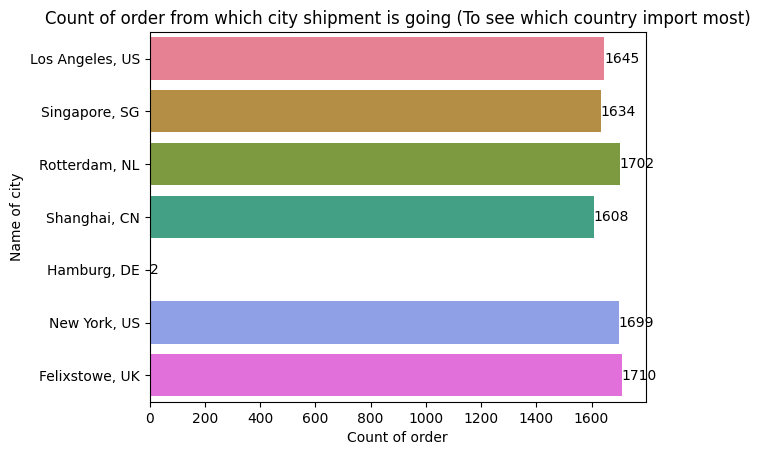

In [13]:
# Count of order from which city shipment is going (To see which country import most)
ax = sns.countplot(y='Destination_City', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Count of order from which city shipment is going (To see which country import most)")
plt.xlabel("Count of order")
plt.ylabel("Name of city")
plt.show()

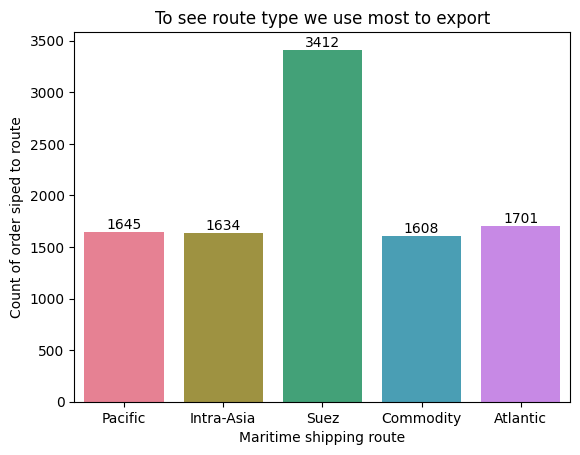

In [14]:
# To see route type we use most to export
ax = sns.countplot(x='Route_Type', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("To see route type we use most to export")
plt.ylabel("Count of order siped to route")
plt.xlabel("Maritime shipping route")
plt.show()

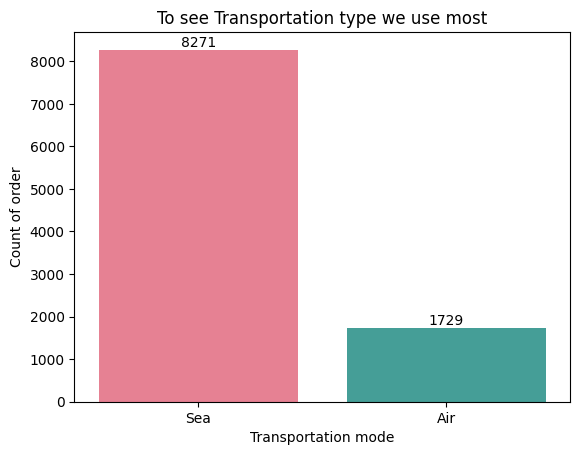

In [15]:
# To see Transportation type we use most
ax = sns.countplot(x='Transportation_Mode', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("To see Transportation type we use most")
plt.ylabel("Count of order")
plt.xlabel("Transportation mode")
plt.show()

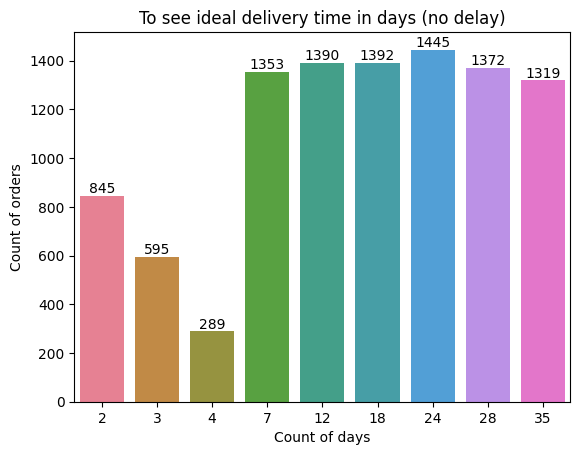

In [16]:
# To see ideal delivery time in days (no delay)
ax = sns.countplot(x='Base_Lead_Time_Days', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("To see ideal delivery time in days (no delay)")
plt.ylabel("Count of orders")
plt.xlabel("Count of days")
plt.show()

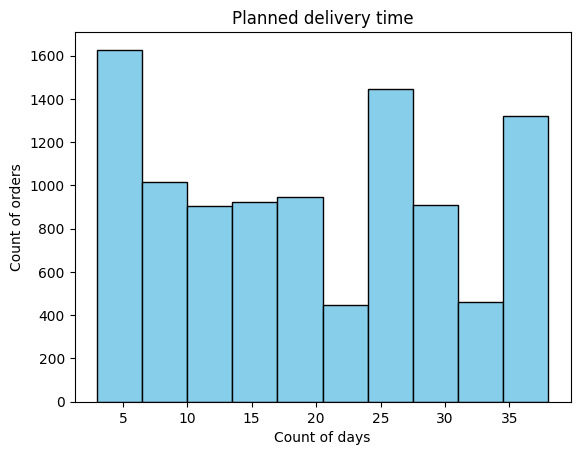

In [17]:
# Planned delivery time
plt.figure()
plt.hist(df["Scheduled_Lead_Time_Days"], bins=10,color='skyblue', edgecolor='black')
plt.title("Planned delivery time")
plt.xlabel("Count of days")
plt.ylabel("Count of orders")
plt.show()

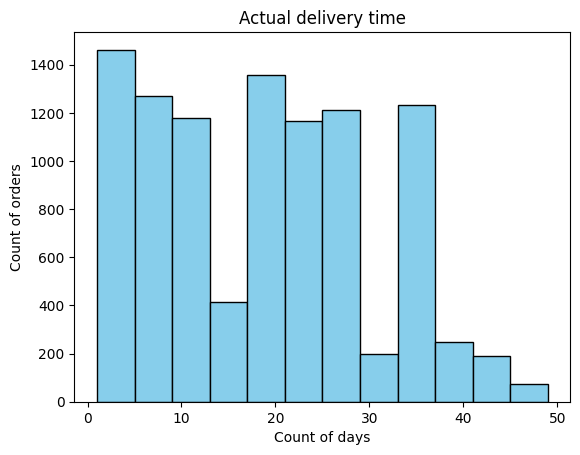

In [18]:
# Actual delivery time
plt.figure()
plt.hist(df["Actual_Lead_Time_Days"], bins=12,color='skyblue', edgecolor='black')
plt.title("Actual delivery time")
plt.xlabel("Count of days")
plt.ylabel("Count of orders")
plt.show()

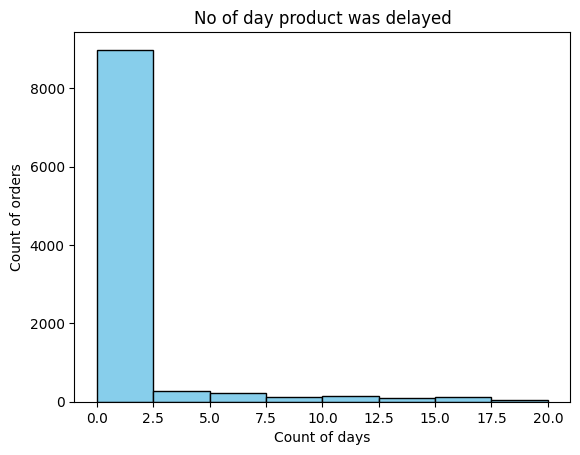

In [19]:
# No of day product was delayed
plt.figure()
plt.hist(df["Delay_Days"], bins=8,color='skyblue', edgecolor='black')
plt.title("No of day product was delayed")
plt.xlabel("Count of days")
plt.ylabel("Count of orders")
plt.show()

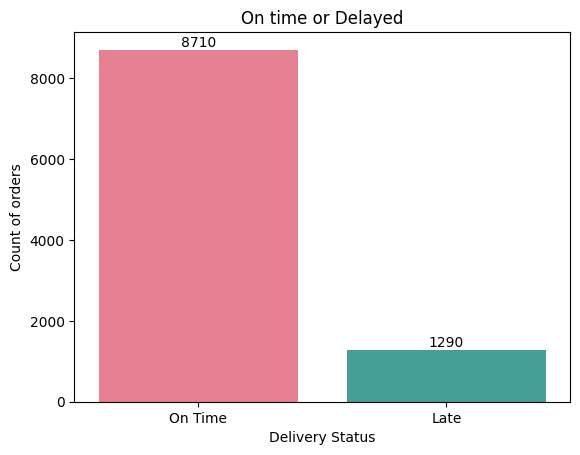

In [20]:
# On time or Delayed
ax = sns.countplot(x='Delivery_Status', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("On time or Delayed")
plt.ylabel("Count of orders")
plt.xlabel("Delivery Status")
plt.show()

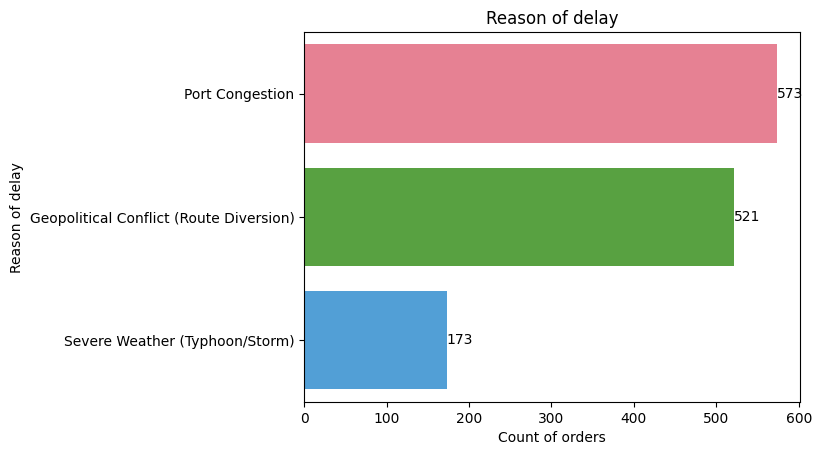

In [21]:
# Reason of delay
ax = sns.countplot(y='Disruption_Event', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Reason of delay")
plt.ylabel("Reason of delay")
plt.xlabel("Count of orders")
plt.show()

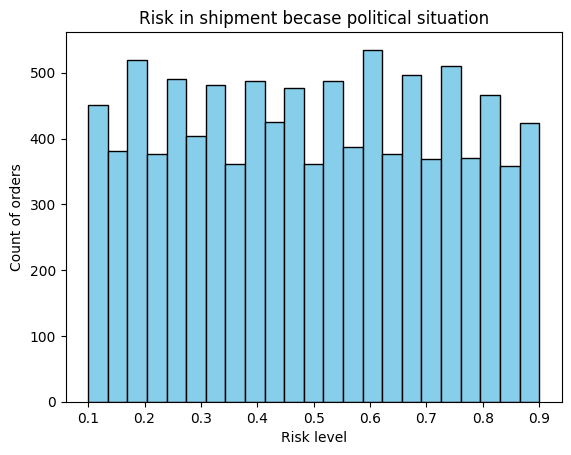

In [22]:
# Risk in shipment becase political situation
plt.figure()
plt.hist(df["Geopolitical_Risk_Index"], bins=23,color='skyblue', edgecolor='black')
plt.title("Risk in shipment becase political situation")
plt.xlabel("Risk level")
plt.ylabel("Count of orders")
plt.show()

In [23]:
# To make it easy to understand
df['Geo_Risk_Level'] = pd.cut(
    df['Geopolitical_Risk_Index'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)
df.drop('Geopolitical_Risk_Index', axis=1, inplace=True)

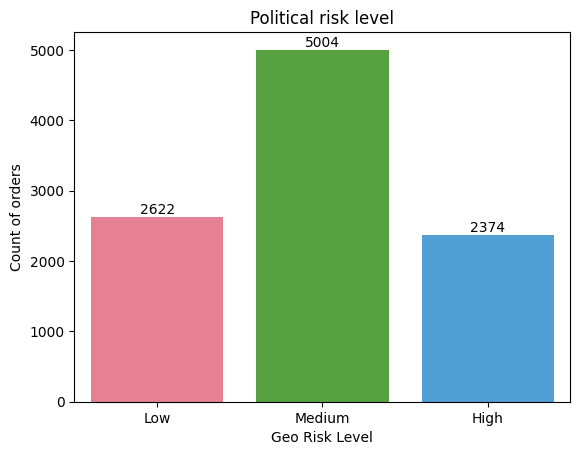

In [24]:
# Political risk level
ax = sns.countplot(x='Geo_Risk_Level', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Political risk level")
plt.xlabel("Geo Risk Level")
plt.ylabel("Count of orders")
plt.show()

In [25]:
# To make it easy to understand
df['Weather_Level'] = pd.cut(
    df['Weather_Severity_Index'],
    bins=[0, 0.3, 0.5, 0.8, 1],
    labels=['Normal', 'Light', 'Moderate', 'Severe']
)
df.drop('Weather_Severity_Index', axis=1, inplace=True)

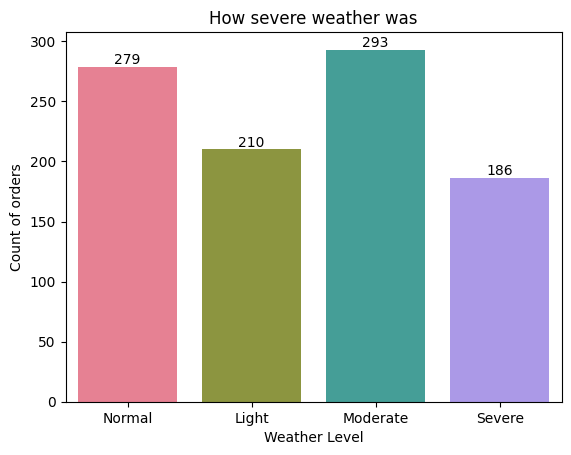

In [26]:
# How severe weather was
ax = sns.countplot(x='Weather_Level', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("How severe weather was")
plt.xlabel("Weather Level")
plt.ylabel("Count of orders")
plt.show()

In [27]:
# To make it easy to understand
df['Inflation_Level'] = pd.cut(
    df['Inflation_Rate_Pct'],
    bins=[0, 2, 5, 10],
    labels=['Low', 'Normal', 'High']
)
df.drop('Inflation_Rate_Pct', axis=1, inplace=True)

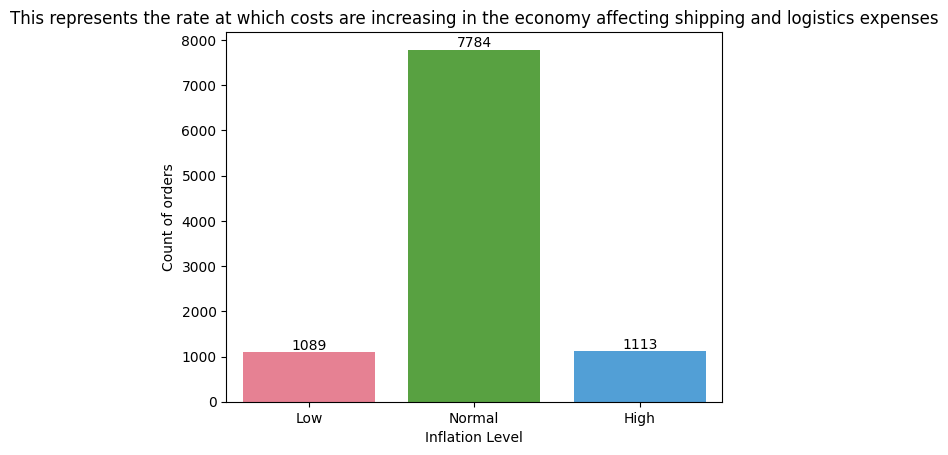

In [28]:
# This represents the rate at which costs are increasing in the economy affecting shipping and logistics expenses
ax= sns.countplot(x='Inflation_Level', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("This represents the rate at which costs are increasing in the economy affecting shipping and logistics expenses")
plt.xlabel("Inflation Level")
plt.ylabel("Count of orders")
plt.show()

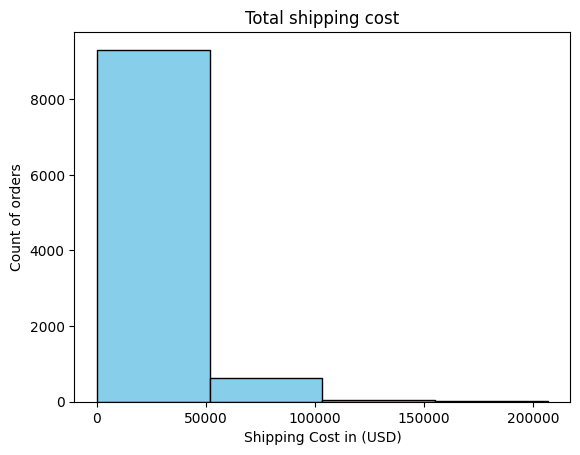

In [29]:
# Total shipping cost
plt.figure()
plt.hist(df["Shipping_Cost_USD"], bins=4,color='skyblue', edgecolor='black')
plt.title("Total shipping cost")
plt.xlabel("Shipping Cost in (USD)")
plt.ylabel("Count of orders")
plt.show()

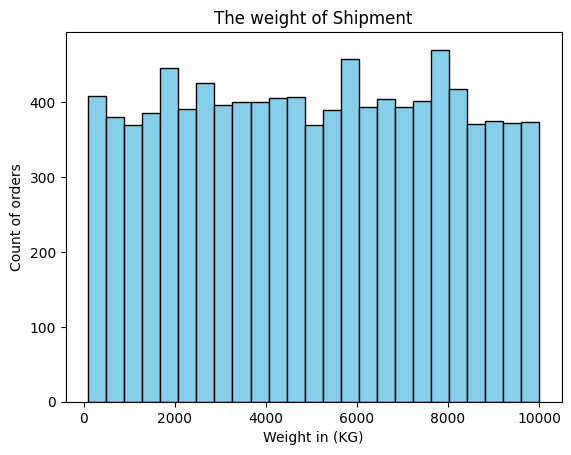

In [30]:
# The weight of Shipment
plt.figure()
plt.hist(df["Order_Weight_Kg"], bins=25,color='skyblue', edgecolor='black')
plt.title("The weight of Shipment")
plt.xlabel("Weight in (KG)")
plt.ylabel("Count of orders")
plt.show()

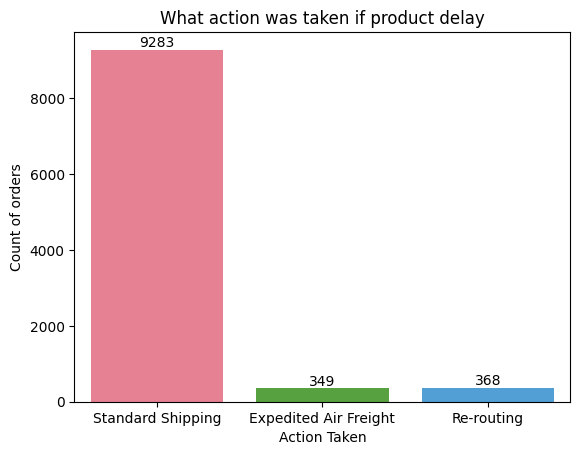

In [31]:
# What action was taken if product delay
ax =sns.countplot(x='Mitigation_Action_Taken', data=df, palette='husl')
for i in ax.containers:
    ax.bar_label(i)
plt.title("What action was taken if product delay")
plt.xlabel("Action Taken")
plt.ylabel("Count of orders")
plt.show()

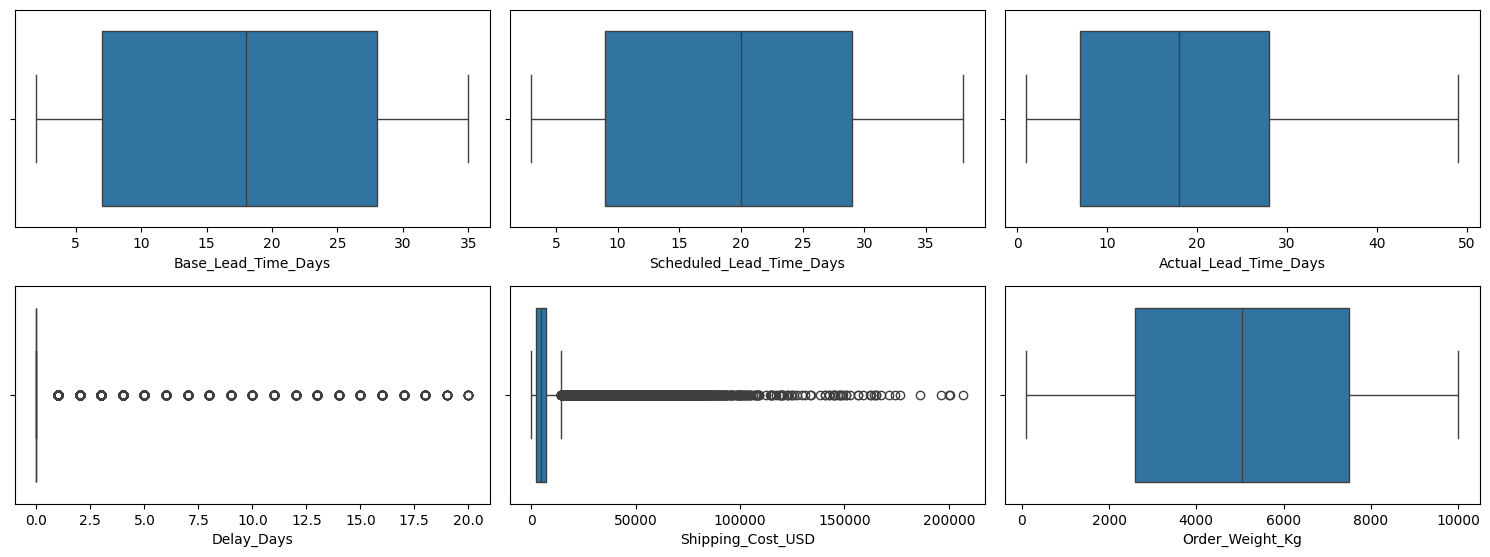

In [32]:
# To see the outliner in boxplot  
plt.figure(figsize=(15,8))
c=1
for i in df.describe().columns:
    plt.subplot(3,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

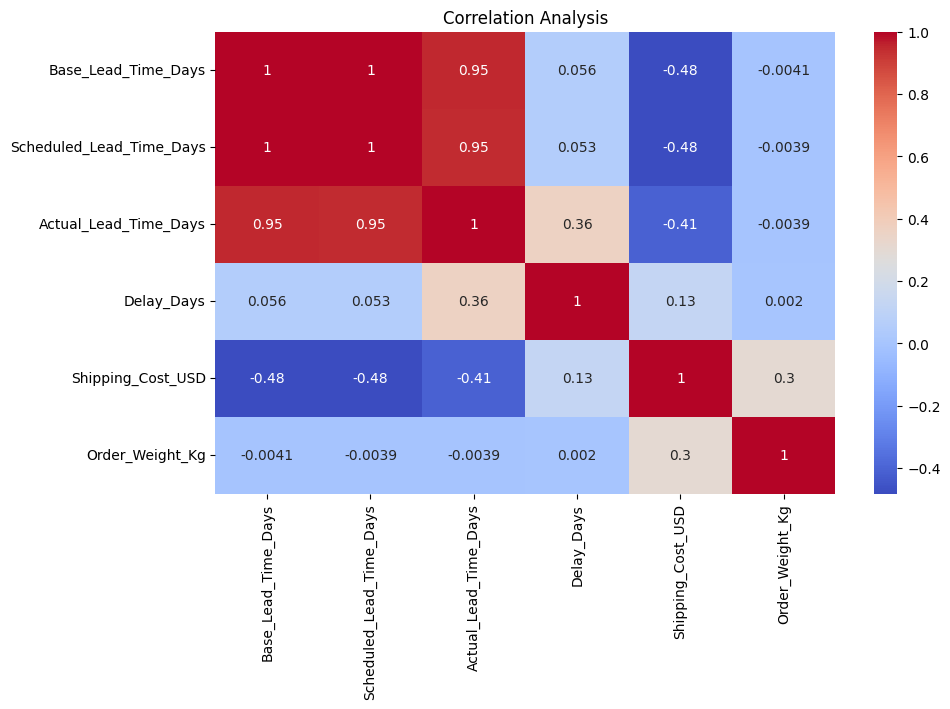

In [33]:
# To see correlation in heatmap 
numeric_cols = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Analysis")
plt.show()

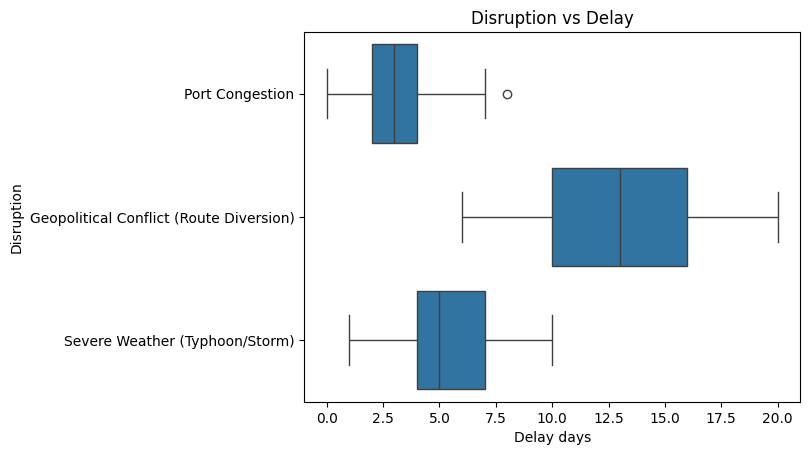

In [34]:
# Disruption vs Delay
sns.boxplot(y='Disruption_Event', x='Delay_Days', data=df)
plt.title("Disruption vs Delay")
plt.xlabel("Delay days")
plt.ylabel("Disruption")
plt.show()

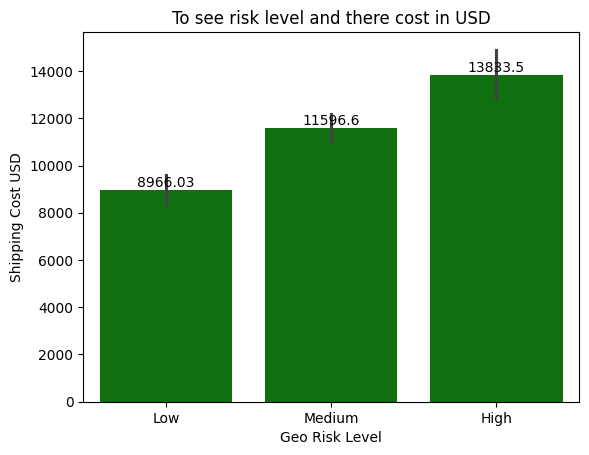

In [35]:
# To see risk level and there cost in USD
ax = sns.barplot(x='Geo_Risk_Level', y='Shipping_Cost_USD', data=df, color="g")
for i in ax.containers:
    ax.bar_label(i)
plt.title("To see risk level and there cost in USD")
plt.xlabel("Geo Risk Level")
plt.ylabel("Shipping Cost USD")
plt.show()

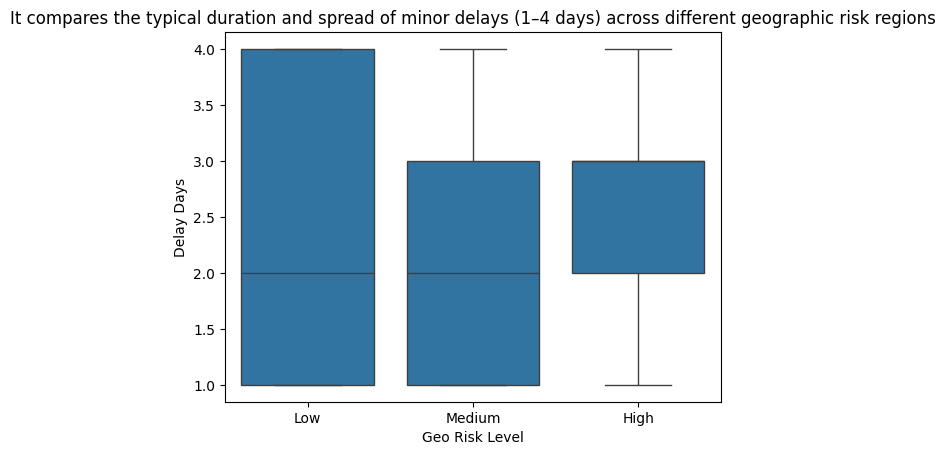

In [36]:
# It compares the typical duration and spread of minor delays (1–4 days) across different geographic risk regions.
sns.boxplot(x='Geo_Risk_Level',y='Delay_Days', data=df[(df['Delay_Days'] > 0) & (df['Delay_Days'] < 5)])
plt.title("It compares the typical duration and spread of minor delays (1–4 days) across different geographic risk regions")
plt.xlabel("Geo Risk Level")
plt.ylabel("Delay Days")
plt.show()

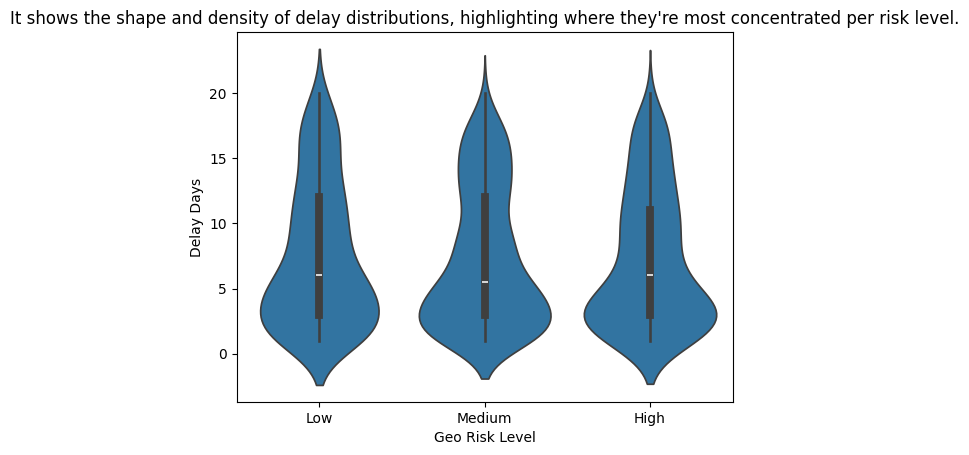

In [37]:
# It shows the shape and density of delay distributions, highlighting where they're most concentrated per risk level.
sns.violinplot(x='Geo_Risk_Level', y='Delay_Days', data=df[df['Delay_Days'] > 0])
plt.title("It shows the shape and density of delay distributions, highlighting where they're most concentrated per risk level.")
plt.xlabel("Geo Risk Level")
plt.ylabel("Delay Days")
plt.show()

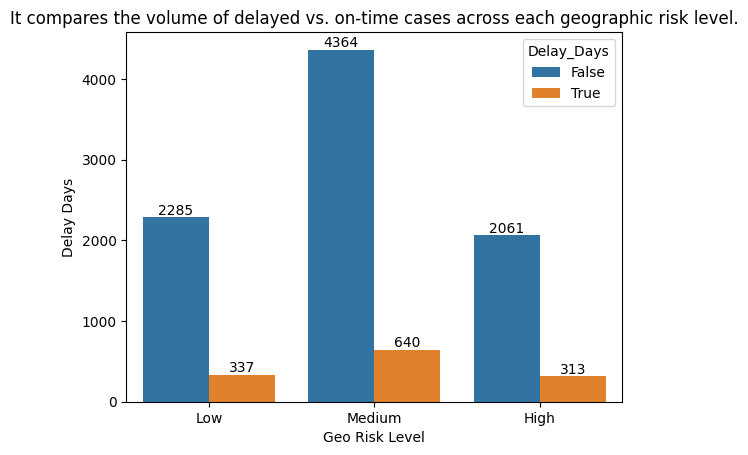

In [38]:
# It compares the volume of delayed vs. on-time cases across each geographic risk level.
ax = sns.countplot(x='Geo_Risk_Level', hue=df['Delay_Days'] > 0, data=df)
for i in ax.containers:
    ax.bar_label(i)
plt.title("It compares the volume of delayed vs. on-time cases across each geographic risk level.")
plt.xlabel("Geo Risk Level")
plt.ylabel("Delay Days")
plt.show()

<Axes: xlabel='Delay_Days', ylabel='Shipping_Cost_USD'>

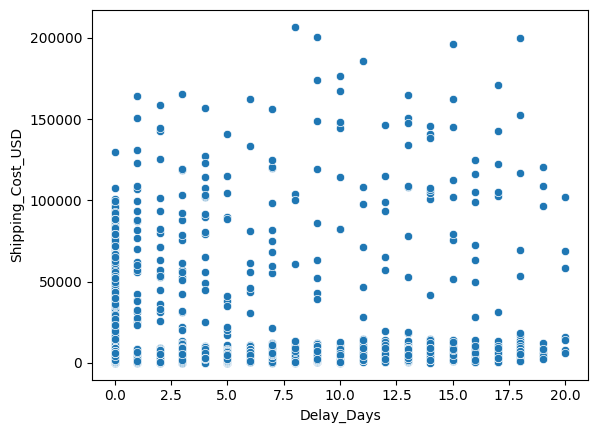

In [39]:
# Cost vs Delay relationship
sns.scatterplot(x='Delay_Days', y='Shipping_Cost_USD', data=df)

# Future Engineering

In [40]:
# To see (high delay) True/False → delay > 3 days 
df['High_Delay'] = df['Delay_Days'] > 3

# Per kg shipping cost in USD
df['Cost_per_kg'] = df['Shipping_Cost_USD'] / df['Order_Weight_Kg']

# Extra delay beyond plan
df['Extra_Delay'] = df['Actual_Lead_Time_Days'] - df['Scheduled_Lead_Time_Days']

# expected cost based on weight
df['Expected_Cost'] = df['Order_Weight_Kg'] * df['Cost_per_kg']

# extra cost (risk/loss) in USD
df['Cost_Uplift'] = df['Shipping_Cost_USD'] - df['Expected_Cost']

# convert date to proper format and make date as index (for time analysis)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.set_index('Order_Date', inplace=True)

# monthly average delay and monthly average cost
monthly_delay = df['Delay_Days'].resample('M').mean()
monthly_cost = df['Shipping_Cost_USD'].resample('M').mean()

# top 10% expensive shipments
df['High_Cost'] = df['Shipping_Cost_USD'] > df['Shipping_Cost_USD'].quantile(0.9)

# 1 = delayed, 0 = not delayed and total delayed shipments per month
df['Delay_Flag'] = (df['Delay_Days'] > 0).astype(int)
monthly_count = df['Delay_Flag'].resample('M').sum()

# 1. Fill the missing values permanently
df['Disruption_Event'] = df['Disruption_Event'].fillna('unknown')
df['Weather_Level'] = df['Weather_Level'].astype(str).replace('nan', 'unknown')

# Business Insigh

**GROUP 1: Cost Analysis**

In [41]:
# Avg cost per risk level “High risk → cost increase?”
df.groupby('Geo_Risk_Level')['Shipping_Cost_USD'].mean()

Geo_Risk_Level
Low        8966.027300
Medium    11596.633935
High      13833.480868
Name: Shipping_Cost_USD, dtype: float64

In [42]:
# Which disruption causes highest cost “Most expensive disruption = Geopolitical Conflict (Route Diversion)”
df.groupby('Disruption_Event')['Shipping_Cost_USD'].mean()

Disruption_Event
Geopolitical Conflict (Route Diversion)    23022.959079
Port Congestion                            15530.430349
Severe Weather (Typhoon/Storm)             12529.558208
unknown                                    10456.618748
Name: Shipping_Cost_USD, dtype: float64

In [43]:
# How often each disruption happens
df.groupby('Disruption_Event')['Shipping_Cost_USD'].count()

Disruption_Event
Geopolitical Conflict (Route Diversion)     521
Port Congestion                             573
Severe Weather (Typhoon/Storm)              173
unknown                                    8733
Name: Shipping_Cost_USD, dtype: int64

In [44]:
# Total cost impact per disruption “Which disruption costs company most overall”
df.groupby('Disruption_Event')['Shipping_Cost_USD'].sum()

Disruption_Event
Geopolitical Conflict (Route Diversion)    11994961.68
Port Congestion                             8898936.59
Severe Weather (Typhoon/Storm)              2167613.57
unknown                                    91317651.53
Name: Shipping_Cost_USD, dtype: float64

In [45]:
# Cost per kg comparison
df.groupby('Disruption_Event')['Cost_per_kg'].mean().sort_values(ascending=False)

Disruption_Event
Geopolitical Conflict (Route Diversion)    4.467762
Port Congestion                            3.055327
Severe Weather (Typhoon/Storm)             2.680976
unknown                                    2.051610
Name: Cost_per_kg, dtype: float64

**GROUP 2: Delay Analysis**

In [46]:
# Avg delay by risk
df.groupby('Geo_Risk_Level')['Delay_Days'].mean()

Geo_Risk_Level
Low       0.967582
Medium    0.935252
High      0.951137
Name: Delay_Days, dtype: float64

In [47]:
# Full delay picture (normal + extreme) Max = real risk
df.groupby('Geo_Risk_Level')['Delay_Days'].agg(['mean','median','max'])

,mean,median,max
Geo_Risk_Level,,,
Low,0.967582,0.0,20
Medium,0.935252,0.0,20
High,0.951137,0.0,20


In [48]:
# % of delayed shipments
(df['Delay_Days'] > 0).groupby(df['Geo_Risk_Level']).mean()

Geo_Risk_Level
Low       0.128528
Medium    0.127898
High      0.131845
Name: Delay_Days, dtype: float64

In [49]:
# Combined impact (very important)“High risk + bad weather = worst delays
df.groupby(['Geo_Risk_Level','Weather_Level'])['Delay_Days'].mean()

Geo_Risk_Level  Weather_Level
Low             Light            0.883333
                Moderate         0.538462
                Normal           0.803030
                Severe           0.403226
                unknown          1.003396
Medium          Light            0.979381
                Moderate         1.025641
                Normal           0.503650
                Severe           0.738636
                unknown          0.948078
High            Light            1.471698
                Moderate         0.898305
                Normal           0.605263
                Severe           0.083333
                unknown          0.966512
Name: Delay_Days, dtype: float64

In [50]:
# Delay by transport 
df.groupby('Transportation_Mode')['Delay_Days'].mean()

Transportation_Mode
Air    0.917872
Sea    0.953694
Name: Delay_Days, dtype: float64

**GROUP 3: High Delay Cases (MOST IMPORTANT)**

In [51]:
# What causes big delays
df[df['Delay_Days'] > 3]['Disruption_Event'].value_counts()

Disruption_Event
Geopolitical Conflict (Route Diversion)    521
Port Congestion                            222
Severe Weather (Typhoon/Storm)             139
Name: count, dtype: int64

In [52]:
# Avg cost when delay high
round(df[df['Delay_Days'] > 3]['Shipping_Cost_USD'].mean(),2)

np.float64(19077.4)

In [53]:
# Avg cost when delay low Compare = financial impact of delay
round(df[df['Delay_Days'] <= 3]['Shipping_Cost_USD'].mean(),2)

np.float64(10698.94)

In [54]:
# Which cities have problems in Delay Days
df[df['Delay_Days'] > 3]['Destination_City'].value_counts()

Destination_City
Felixstowe, UK     280
Rotterdam, NL      241
Singapore, SG      118
Los Angeles, US    102
New York, US        78
Shanghai, CN        63
Name: count, dtype: int64

In [55]:
# Which transport causes delay 
df[df['Delay_Days'] > 3]['Transportation_Mode'].value_counts()

Transportation_Mode
Sea    741
Air    141
Name: count, dtype: int64

In [56]:
# Compare good vs bad transport
df[df['Delay_Days'] <= 3]['Transportation_Mode'].value_counts()

Transportation_Mode
Sea    7530
Air    1588
Name: count, dtype: int64

In [57]:
# Add % impact (VERY IMPORTANT)
high_delay_pct = (df['Delay_Days'] > 3).mean()
print(high_delay_pct)

0.0882


In [58]:
# Cost difference (strong insight)
df.groupby(df['Delay_Days'] > 3)['Shipping_Cost_USD'].mean()

Delay_Days
False    10698.935340
True     19077.404694
Name: Shipping_Cost_USD, dtype: float64

**GROUP 4: Root Cause**

In [59]:
# Worst disruption for delay
df.groupby('Disruption_Event')['Delay_Days'].mean().sort_values(ascending=False)

Disruption_Event
Geopolitical Conflict (Route Diversion)    12.930902
Severe Weather (Typhoon/Storm)              5.508671
Port Congestion                             2.986038
unknown                                     0.008474
Name: Delay_Days, dtype: float64

In [60]:
# Multi-factor root cause
df.groupby(['Disruption_Event','Transportation_Mode'])['Delay_Days'].mean()

Disruption_Event                         Transportation_Mode
Geopolitical Conflict (Route Diversion)  Air                    13.098901
                                         Sea                    12.895349
Port Congestion                          Air                     2.781250
                                         Sea                     3.027254
Severe Weather (Typhoon/Storm)           Air                     5.227273
                                         Sea                     5.549669
unknown                                  Air                     0.008553
                                         Sea                     0.008457
Name: Delay_Days, dtype: float64

In [61]:
# Extra cost distribution
df['Cost_Uplift'].describe()

count    1.000000e+04
mean    -4.420286e-15
std      9.370137e-13
min     -1.455192e-11
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.455192e-11
Name: Cost_Uplift, dtype: float64

In [62]:
# How many high-cost shipments
df['High_Cost'].value_counts()

High_Cost
False    9000
True     1000
Name: count, dtype: int64

In [63]:
# Which disruption causes extreme cost
df[df['High_Cost']].groupby('Disruption_Event')['Shipping_Cost_USD'].mean()

Disruption_Event
Geopolitical Conflict (Route Diversion)    109549.420843
Port Congestion                             91279.786714
Severe Weather (Typhoon/Storm)              86757.796875
unknown                                     60763.424428
Name: Shipping_Cost_USD, dtype: float64

In [64]:
# Top 5 costly shipments
df.nlargest(5, 'Shipping_Cost_USD')

,Order_ID,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,...,Geo_Risk_Level,Weather_Level,Inflation_Level,High_Delay,Cost_per_kg,Extra_Delay,Expected_Cost,Cost_Uplift,High_Cost,Delay_Flag
Order_Date,,,,,,,,,,,,,,,,,,,,,
2024-12-14,ORD-E4DE8327,"Mumbai, IN","Felixstowe, UK",Suez,Air,Auto Parts,3,6,14,8,...,High,Light,Normal,True,23.099999,8,206814.29,0.0,True,1
2025-11-06,ORD-EB18DCD6,"Mumbai, IN","Felixstowe, UK",Suez,Air,Auto Parts,3,5,14,9,...,Medium,unknown,Normal,True,21.252000,9,200576.38,0.0,True,1
2025-06-18,ORD-89FBF9AB,"Mumbai, IN","Felixstowe, UK",Suez,Air,Auto Parts,3,4,22,18,...,High,unknown,Normal,True,23.760000,18,199940.40,0.0,True,1
2025-04-27,ORD-5D38002A,"Mumbai, IN","Felixstowe, UK",Suez,Air,Auto Parts,3,5,20,15,...,Medium,unknown,Normal,True,19.667999,15,196188.29,0.0,True,1
2024-12-06,ORD-7D039269,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Auto Parts,3,4,15,11,...,Medium,unknown,Normal,True,22.308000,11,185959.49,0.0,True,1


In [65]:
# Tail risk percentage
(df['High_Cost'].mean()) * 100

np.float64(10.0)

In [66]:
# Cost uplift by disruption
df.groupby('Disruption_Event')['Cost_Uplift'].mean().sort_values(ascending=False)

Disruption_Event
Geopolitical Conflict (Route Diversion)    1.212150e-13
Port Congestion                            3.224103e-14
unknown                                   -1.309374e-14
Severe Weather (Typhoon/Storm)            -6.637208e-14
Name: Cost_Uplift, dtype: float64

In [67]:
# Groups data by mitigation type and calculates the average delay for each.
df.groupby('Mitigation_Action_Taken')['Delay_Days'].mean() 

Mitigation_Action_Taken
Expedited Air Freight     7.782235
Re-routing               12.817935
Standard Shipping         0.219972
Name: Delay_Days, dtype: float64

In [68]:
# Average Shipping Cost per Mitigation Action
df.groupby('Mitigation_Action_Taken')['Shipping_Cost_USD'].mean()

Mitigation_Action_Taken
Expedited Air Freight    53130.100602
Re-routing                6078.466495
Standard Shipping        10082.934675
Name: Shipping_Cost_USD, dtype: float64

<Axes: title={'center': 'Monthly Delay Trend'}, xlabel='Order_Date'>

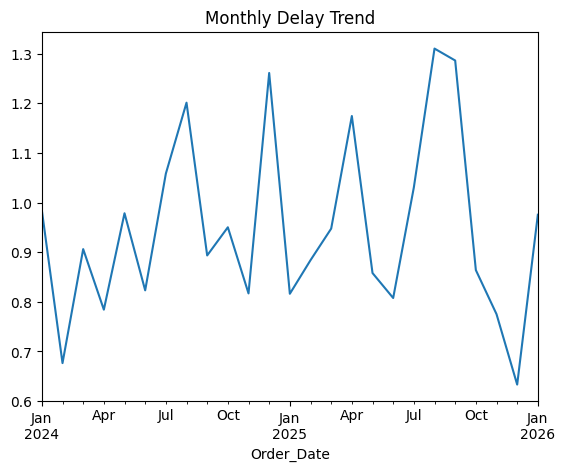

In [69]:
# Monthly Delay Trend Plot
monthly_delay.plot(title="Monthly Delay Trend")

In [70]:
# ARIMA is a model used to predict future values based on past data (time series)
from statsmodels.tsa.arima.model import ARIMA

# Initializes the ARIMA model with (p,d,q) parameters (Lag, Differencing, Moving Average)
model = ARIMA(monthly_delay, order=(1,1,1))
# Trains the model on your monthly delay data
model_fit = model.fit()

# Predicts the average delay for the next 4 months
forecast = model_fit.forecast(steps=4)

print(forecast)

# Future delays are expected to remain stable around 1 day, with no major increase in risk. 
# ARIMA forecasting indicates that average shipment delays will remain stable at approximately one day over the next four months.

2026-02-28    0.952602
2026-03-31    0.949087
2026-04-30    0.948549
2026-05-31    0.948467
Freq: ME, Name: predicted_mean, dtype: float64


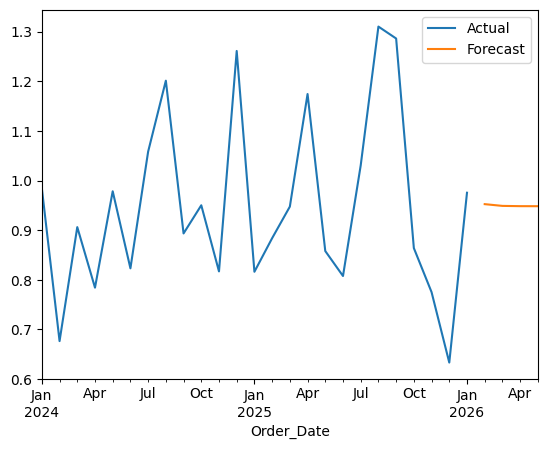

In [71]:
import matplotlib.pyplot as plt

# Plots the historical monthly delay data
monthly_delay.plot(label='Actual')
# Plots the 4-month ARIMA prediction on the same graph
forecast.plot(label='Forecast')

# Adds a legend to distinguish between past data and future predictions
plt.legend()
# Renders the chart
plt.show()

In [72]:
import pandas as pd
import statsmodels.api as sm

# Prepares features (X): extracts month from index and uses average delay as a predictor
X = pd.DataFrame({
    'month': monthly_count.index.month,
    'delay_avg': monthly_delay.values
}, index=monthly_count.index)

# Adds a constant (intercept) to the model for mathematical accuracy
X = sm.add_constant(X)

# Fits a Poisson Generalized Linear Model to predict the count of delay events
poisson_model = sm.GLM(monthly_count, X, family=sm.families.Poisson()).fit()

# Displays statistical summary (p-values, coefficients) to show feature impact
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Delay_Flag   No. Observations:                   25
Model:                            GLM   Df Residuals:                       22
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -110.20
Date:                Wed, 25 Mar 2026   Deviance:                       77.525
Time:                        20:15:47   Pearson chi2:                     54.9
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6982
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1852      0.150     21.298      0.0

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Target: The value you want to predict
y = df['Shipping_Cost_USD']

# Features: The input variables used for the prediction
X = df[['Origin_City','Destination_City','Route_Type','Transportation_Mode','Product_Category', 'Base_Lead_Time_Days','Scheduled_Lead_Time_Days',
    'Actual_Lead_Time_Days', 'Delay_Days','Order_Weight_Kg','Geo_Risk_Level','Weather_Level','Inflation_Level','High_Delay','Delay_Flag','High_Cost',
    'Cost_per_kg','Extra_Delay','Cost_Uplift','Disruption_Event','Mitigation_Action_Taken']]

# Defining column types for specialized processing
num_cols = ['Base_Lead_Time_Days','Scheduled_Lead_Time_Days','Actual_Lead_Time_Days','Delay_Days','Order_Weight_Kg','Cost_per_kg','Extra_Delay',
    'Cost_Uplift']

cat_cols = ['Origin_City','Destination_City','Route_Type','Transportation_Mode','Product_Category','Geo_Risk_Level','Weather_Level','Inflation_Level',
    'Disruption_Event','Mitigation_Action_Taken','High_Delay','Delay_Flag','High_Cost']

# Preprocessing: Preparing numerical data for the model
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols)
])

# One-Hot Encoding: Converting categories into binary (0/1) columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Data Splitting: Reserving 20% of data for testing model accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Feature Scaling: Normalizing numerical features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

# Dictionary to store and iterate through different ML algorithms
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor()    
}

# Training Loop: Fits each model to the training data and evaluates on test data
for name, m in models.items():
    m.fit(X_train, y_train) # Trains the model
    pred = m.predict(X_test) # Makes predictions
    
    print(name)
    # R² Score: Accuracy of the fit (closer to 1.0 is better)
    print("Score (R²):", m.score(X_test, y_test))
    # MAE: Average absolute error in shipping cost units
    print("MAE:", mean_absolute_error(y_test, pred))
    # RMSE: Penalizes larger errors more heavily than MAE
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("-"*32)

Linear
Score (R²): 0.9054956225498071
MAE: 3015.2019733166126
RMSE: 6263.905627698766
--------------------------------
RandomForest
Score (R²): 0.9968400956507942
MAE: 199.61740254999935
RMSE: 1145.3974490848798
--------------------------------
GradientBoostingRegressor
Score (R²): 0.9963473193698159
MAE: 449.28893289483403
RMSE: 1231.473566117456
--------------------------------


In [75]:
import numpy as np
import statsmodels.api as sm

# Standardizing Header Names: Ensures consistency by removing spaces and making lowercase.
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Log Transformation: Normalizes skewed data (Cost and Weight) to improve model linearity.
df['log_cost'] = np.log(df['shipping_cost_usd'])
df['log_weight'] = np.log(df['order_weight_kg'])

# Dynamic Feature Selection: Automatically picks all One-Hot encoded disruption columns.
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]

# Feature Isolation: Sets up predictors and the target variable.
X = df[['log_weight', 'delay_days'] + dummy_cols].copy()
y = df['log_cost'].copy()

# Type Conversion: Ensures boolean flags and strings are strictly numeric (0/1).
X = X.replace({True: 1, False: 0})
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Data Cleaning: Drops rows with missing values to prevent model failure.
df_model = pd.concat([X, y], axis=1).dropna()
X = df_model[X.columns].astype(float)
y = df_model[y.name].astype(float)

# Statistical Setup: Adds an intercept (constant) and fits the Ordinary Least Squares model.
X = sm.add_constant(X)
# Robust Estimation: Uses HC3 covariance to handle heteroscedasticity (uneven variance).
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4951.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:07   Log-Likelihood:                -13565.
No. Observations:               10000   AIC:                         2.714e+04
Df Residuals:                    9997   BIC:                         2.716e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0330      0.085     -0.387      0.6

In [76]:
import statsmodels.api as sm
import numpy as np

# Feature Selection: Identifies categorical disruption columns for the model.
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]

X = df[['log_weight', 'delay_days'] + dummy_cols].copy()
y = df['log_cost'].copy()

# Step 1: Boolean Conversion: Turns True/False flags into binary 1/0 for math processing.
X = X.replace({True: 1, False: 0})

# Step 2: Numeric Enforcement: Converts all data to numeric, turning errors into NaNs.
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Step 3: Handling Missing Data: Removes any rows containing NaNs to ensure model stability.
df_model = pd.concat([X, y], axis=1).dropna()

X = df_model[X.columns]
y = df_model[y.name]

# Step 4: Float Casting: Ensures all data is in float64 format to prevent statsmodels errors.
X = X.astype(float)
y = y.astype(float)

# Step 5: Intercept Addition: Adds a 'const' column so the regression line isn't forced through zero.
X = sm.add_constant(X)

# Step 6: Debugging: Prints data types to verify all columns are numeric before fitting.
print(X.dtypes)

# Statistical Fitting: Executes OLS with HC3 robust standard errors to handle variance issues.
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

const         float64
log_weight    float64
delay_days    float64
dtype: object
                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4951.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:07   Log-Likelihood:                -13565.
No. Observations:               10000   AIC:                         2.714e+04
Df Residuals:                    9997   BIC:                         2.716e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [77]:
import numpy as np
import statsmodels.api as sm

# Log transform
df['log_cost'] = np.log(df['shipping_cost_usd'])
import numpy as np
import statsmodels.api as sm

# Log Transformation: Scaling skewed target and predictor variables.
df['log_cost'] = np.log(df['shipping_cost_usd'])
df['log_weight'] = np.log(df['order_weight_kg'])

# Feature Selection: Collecting dummy-coded disruption columns.
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]

# X and y creation: Defining predictors and the target.
X = df[['log_weight', 'delay_days'] + dummy_cols].copy()
y = df['log_cost'].copy()

# FIX 1: Boolean conversion: Iterating through columns to force True/False to 1/0.
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# FIX 2: Numeric Force: Cleaning any non-numeric strings into NaNs.
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# FIX 3: Row Alignment: Dropping rows where data is missing in either X or y.
df_model = pd.concat([X, y], axis=1).dropna()
X = df_model[X.columns]
y = df_model[y.name]

# FIX 4: Final Type Casting: Ensuring all values are 64-bit floats for the solver.
X = X.astype(float)
y = y.astype(float)

# Intercept: Adding a constant term for the regression equation.
X = sm.add_constant(X)

# Statistical Fit: Executing OLS with Robust Standard Errors (HC3).
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())
df['log_weight'] = np.log(df['order_weight_kg'])

# Select dummy columns
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]

# Create X and y
X = df[['log_weight', 'delay_days'] + dummy_cols].copy()
y = df['log_cost'].copy()

# FIX 1: convert bool → int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# FIX 2: force numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# FIX 3: drop NaN rows
df_model = pd.concat([X, y], axis=1).dropna()

X = df_model[X.columns]
y = df_model[y.name]

# FIX 4: convert to float (MOST IMPORTANT)
X = X.astype(float)
y = y.astype(float)

# Add constant AFTER cleaning
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4951.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:07   Log-Likelihood:                -13565.
No. Observations:               10000   AIC:                         2.714e+04
Df Residuals:                    9997   BIC:                         2.716e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0330      0.085     -0.387      0.6

In [78]:
# Step 1: Identifies the dummy-coded disruption variables used during model training.
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]

# Step 2: Replicates the feature set (Weight, Delay, and Disruptions).
X_full = df[['log_weight', 'delay_days'] + dummy_cols].copy()

# Step 3: Standardizes boolean values to binary integers (0/1).
X_full = X_full.replace({True: 1, False: 0})

# Step 4: Forces all columns to be numeric, handling any non-numeric strings as NaNs.
X_full = X_full.apply(pd.to_numeric, errors='coerce')

# Step 5: Casts the entire matrix to float64 to ensure compatibility with statsmodels.
X_full = X_full.astype(float)

# Step 6: Appends the constant (intercept) column required by the OLS model.
X_full = sm.add_constant(X_full)

# Step 7: Ensures the column order and presence match the trained model exactly.
X_full = X_full.reindex(columns=model.model.exog_names, fill_value=0)

# Step 8: Generates predictions in the log-scale.
df['pred_log_cost'] = model.predict(X_full)

# Step 9: Reverses the log-transformation to get costs back into USD.
df['pred_cost'] = np.exp(df['pred_log_cost'])

# Step 10: Measures the percentage by which actual cost exceeded the predicted "normal" cost.
df['cost_uplift_pct'] = (
    (df['shipping_cost_usd'] - df['pred_cost']) / df['pred_cost']
)

# Step 11: Displays the comparison between actual, predicted, and the calculated uplift.
print(df[['shipping_cost_usd', 'pred_cost', 'cost_uplift_pct']].head())

            shipping_cost_usd    pred_cost  cost_uplift_pct
Order_Date                                                 
2024-04-05            1611.81  1981.617551        -0.186619
2024-09-08           76127.70  9319.845050         7.168344
2025-01-28           13699.18  1896.645439         6.222847
2025-02-04            5448.24  6592.507403        -0.173571
2025-05-20            1215.98  1741.611957        -0.301808


In [79]:
from scipy.stats import pearsonr, spearmanr

# Pearson Correlation: Measures the linear relationship between Delay and Cost.
pearson_corr, p_val = pearsonr(df['delay_days'], df['shipping_cost_usd'])

# Spearman Correlation: Measures the monotonic relationship (rank-based), 
# making it more robust to outliers and non-linear patterns.
spearman_corr, sp_p = spearmanr(df['delay_days'], df['shipping_cost_usd'])

# Output: Prints coefficients (strength) and p-values (statistical significance).
print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {p_val:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {sp_p:.5f}")

Pearson Correlation: 0.130, p-value: 0.00000
Spearman Correlation: 0.101, p-value: 0.00000


In [80]:
# STEP 1: CREATE DATE COLUMN
# Generates a synthetic daily timeline to enable time-series operations.
df['date'] = pd.date_range(
    start='2023-01-01', 
    periods=len(df), 
    freq='D'
)

# STEP 2: CREATE MONTHLY DATA
# Aggregates daily data into monthly buckets, calculating averages and totals.
monthly = df.resample('M', on='date').agg({
    'cost_uplift_pct': 'mean',
    'delay_days': 'mean',
    'order_weight_kg': 'sum'
})

# Cleans data and trims the timeline to the most recent 24 months for relevance.
monthly = monthly.dropna().tail(24)

# Re-aligns the index to ensure a continuous, clean monthly timeline.
monthly.index = pd.date_range(
    start='2023-01-01', 
    periods=len(monthly), 
    freq='M'
)

# STEP 3: SARIMAX MODEL
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Defines external factors (Delay and Weight) that help explain Cost Uplift.
exog = monthly[['delay_days', 'order_weight_kg']]

# Initializes SARIMAX: Handles trend (1,1,1) and 12-month seasonality (1,1,1,12).
model = SARIMAX(
    monthly['cost_uplift_pct'],
    exog=exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# Trains the model using the historical data and external variables.
result = model.fit()

# STEP 4: FORECAST
# Predicts the next 4 months using the most recent external data as a baseline.
forecast = result.get_forecast(
    steps=4, 
    exog=exog.tail(4)
)

forecast_values = forecast.predicted_mean

# STEP 5: OUTPUT
print("\n Forecasted Cost Uplift (Next 4 Months):\n")

for date, value in forecast_values.items():
    print(f"{date.strftime('%Y-%m-%d')} → {value:.4f}")


 Forecasted Cost Uplift (Next 4 Months):

2025-01-31 → 0.6496
2025-02-28 → 0.5479
2025-03-31 → 1.0710
2025-04-30 → 0.0876


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [81]:
# FINANCIAL IMPACT (THESIS OUTPUT)

# Baseline cost estimation: Scales current average costs to match monthly weight volumes
baseline_cost = (
    monthly['order_weight_kg'] 
    * df['shipping_cost_usd'].mean() 
    / df['order_weight_kg'].mean()
)

# Expected financial loss: Multiplies the predicted uplift % by the baseline monthly cost
# forecast_values comes from your previous SARIMAX step
expected_loss = baseline_cost.tail(4).values * forecast_values.values

# FORMATTED OUTPUT

print("\n Forecasted Cost Uplift & Financial Impact (Next 4 Months)\n")
print("=" * 65)
print(f"{'Month':<15}{'Cost Uplift (%)':<20}{'Expected Loss ($)':<20}")
print("=" * 65)

# Iterates through the forecast dates, uplift percentages, and calculated dollar losses
for (date, uplift), loss in zip(forecast_values.items(), expected_loss):
    print(f"{date.strftime('%Y-%m-%d'):<15}{uplift:<20.4f}{loss:,.2}{' $':<5}")

print("=" * 65)


 Forecasted Cost Uplift & Financial Impact (Next 4 Months)

Month          Cost Uplift (%)     Expected Loss ($)   
2025-01-31     0.6496              2e+05 $   
2025-02-28     0.5479              2e+05 $   
2025-03-31     1.0710              3.2e+05 $   
2025-04-30     0.0876              2e+04 $   


In [82]:
# Create delay count properly: Converts delay days into a binary 1 (Delayed) or 0 (On-time)
delay_series = (df['delay_days'] > 0).astype(int)

# Combine with date: Links the delay flags to their specific timestamps
delay_df = pd.DataFrame({
    'date': df['date'],
    'delay_flag': delay_series
})

# Resample correctly: Aggregates total number of delay events per month
monthly_delay = delay_df.resample('M', on='date').sum()

# Add to monthly: Integrates the event counts into your main monthly dataframe
monthly['delay_count'] = monthly_delay['delay_flag']

import statsmodels.api as sm

# Features: Testing if total weight volume predicts the number of delays
X_pois = sm.add_constant(monthly[['order_weight_kg']])
y_pois = monthly['delay_count']

# Fit model: Using a Poisson Generalized Linear Model (GLM) for count data
poisson_model = sm.GLM(y_pois, X_pois, family=sm.families.Poisson()).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            delay_count   No. Observations:                   24
Model:                            GLM   Df Residuals:                       22
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -42.224
Date:                Wed, 25 Mar 2026   Deviance:                       7.6820
Time:                        20:16:08   Pearson chi2:                     7.41
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1090
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.6903      0.779     

In [83]:
import statsmodels.api as sm

# Fits a Negative Binomial Generalized Linear Model
# This is used when the variance of your delay counts is much higher than the mean (overdispersion)
nb_model = sm.GLM(
    y_pois, X_pois, 
    family=sm.families.NegativeBinomial()
).fit()

print("\n NEGATIVE BINOMIAL MODEL SUMMARY\n")
print(nb_model.summary())


 NEGATIVE BINOMIAL MODEL SUMMARY

                 Generalized Linear Model Regression Results                  
Dep. Variable:            delay_count   No. Observations:                   24
Model:                            GLM   Df Residuals:                       22
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -59.522
Date:                Wed, 25 Mar 2026   Deviance:                       1.7230
Time:                        20:16:08   Pearson chi2:                     1.53
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02486
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const  

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [84]:
# MODEL EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Isolates the actual historical cost uplift for the last 4 months to compare with predictions
actual = monthly['cost_uplift_pct'][-4:]
# The predicted values generated by the SARIMAX model
pred = forecast_values

# MAE: Represents the average error magnitude in the same units as cost_uplift_pct
mae = mean_absolute_error(actual, pred)
# RMSE: Highlights larger errors by squaring them before averaging
rmse = np.sqrt(mean_squared_error(actual, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.39726517588481003
RMSE: 0.529790327017193


In [85]:
# STATISTICAL TESTING (FINAL THESIS VERSION)
from scipy.stats import pearsonr, spearmanr

# Pearson Correlation: Measures the linear relationship (straight line) between Delay and Cost.
pearson_corr, pearson_p = pearsonr(
    df['delay_days'], 
    df['shipping_cost_usd']
)

# Spearman Correlation: Measures the monotonic relationship (rank-based).
# More robust to outliers and non-linear (curved) patterns.
spearman_corr, spearman_p = spearmanr(
    df['delay_days'], 
    df['shipping_cost_usd']
)

# CLEAN OUTPUT
print("\n CORRELATION ANALYSIS\n")
print("=" * 40)

# A p-value < 0.05 generally indicates the relationship is statistically significant.
print(f"Pearson Correlation  : {pearson_corr:.4f}")
print(f"Pearson p-value      : {pearson_p:.6f}")

print("-" * 40)

print(f"Spearman Correlation : {spearman_corr:.4f}")
print(f"Spearman p-value     : {spearman_p:.6f}")

print("=" * 40)


 CORRELATION ANALYSIS

Pearson Correlation  : 0.1300
Pearson p-value      : 0.000000
----------------------------------------
Spearman Correlation : 0.1011
Spearman p-value     : 0.000000


In [86]:
# TIME SERIES CREATION (FINAL)

# Step 1: Create a synthetic daily date range to enable time-series functionality
df['date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')

# Step 2: Resample to monthly frequency (M) to smooth daily noise
# Calculates average cost uplift, average delays, and total weight moved
monthly = df.resample('M', on='date').agg({
    'cost_uplift_pct': 'mean',
    'delay_days': 'mean',
    'order_weight_kg': 'sum'
}).dropna()

# Step 3: Standardize the timeline to a clean 24-month period
monthly = monthly.tail(24)
monthly.index = pd.date_range(
    start='2023-01-01', 
    periods=len(monthly), 
    freq='M'
)

# SARIMAX MODEL (FINAL)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Exogenous variables: Factors outside the time series that influence the outcome
exog = monthly[['delay_days', 'order_weight_kg']]

# Model Setup:
# order=(1,1,1) -> Autoregressive, Integrated, and Moving Average components
# seasonal_order=(1,1,1,12) -> Accounts for yearly (12-month) seasonality
sarimax_model = SARIMAX(
    monthly['cost_uplift_pct'],
    exog=exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# Training the model
sarimax_result = sarimax_model.fit()

# Forecasting: Predicting 4 steps (months) ahead
# Note: We use the last 4 months of exog as a proxy for future drivers
forecast = sarimax_result.get_forecast(
    steps=4, 
    exog=exog.tail(4)
)

forecast_values = forecast.predicted_mean

# OUTPUT
print("\n Forecasted Cost Uplift (Next 4 Months):\n")

for date, value in forecast_values.items():
    print(f"{date.strftime('%Y-%m-%d')} → {value:.4f}")


 Forecasted Cost Uplift (Next 4 Months):

2025-01-31 → 0.6496
2025-02-28 → 0.5479
2025-03-31 → 1.0710
2025-04-30 → 0.0876


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [87]:
import statsmodels.api as sm
import pandas as pd

# CREATE MONTHLY DELAY COUNT

# Step 1: Binary Flagging
# Converts raw delay days into a simple 1 (Delayed) or 0 (On-time)
delay_df = pd.DataFrame({
    'date': df['date'],
    'delay_flag': (df['delay_days'] > 0).astype(int)
})

# Step 2: Monthly Aggregation
# Sums the flags to get the total number of delay events per month
monthly_delay = delay_df.resample('M', on='date').sum()

# Step 3: Integration
# Merges this count back into your primary monthly analysis dataframe
monthly['delay_count'] = monthly_delay['delay_flag']

# NEGATIVE BINOMIAL MODEL

# Step 4: Model Specification
# Testing if monthly shipping volume (weight) predicts the number of delay incidents
X_nb = sm.add_constant(monthly[['order_weight_kg']])
y_nb = monthly['delay_count']

# Step 5: Fitting the Model
# Negative Binomial is the "Gold Standard" for count data when variance > mean (overdispersion)
nb_model = sm.GLM(
    y_nb, X_nb, 
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            delay_count   No. Observations:                   24
Model:                            GLM   Df Residuals:                       22
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -59.522
Date:                Wed, 25 Mar 2026   Deviance:                       1.7230
Time:                        20:16:10   Pearson chi2:                     1.53
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02486
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.8291      1.823     

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [88]:
# DELAY RATE & SEVERITY

# Step 1: Delay Flagging
# Creates a binary indicator (1 for delayed, 0 for on-time)
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

# Step 2: Overall Delay Rate
# Calculates the percentage of total shipments that experienced a delay
delay_rate = df['is_delayed'].mean()

# Step 3: Delay Severity
# Calculates the average length of delays across the entire dataset
delay_severity = df['delay_days'].mean()

print(f"Overall Delay Rate: {delay_rate:.2%}")
print(f"Average Delay Days: {delay_severity:.2f} days")

# Step 4: Disruption Analysis
# Identifies which specific event types (e.g., Strike, Weather) cause the longest wait times
delay_by_disruption = df.groupby('disruption_event')['delay_days'].mean().sort_values(ascending=False)

print("\nDelay Severity by Disruption (Sorted):\n")
print(delay_by_disruption)

Overall Delay Rate: 12.90%
Average Delay Days: 0.95 days

Delay Severity by Disruption (Sorted):

disruption_event
Geopolitical Conflict (Route Diversion)    12.930902
Severe Weather (Typhoon/Storm)              5.508671
Port Congestion                             2.986038
unknown                                     0.008474
Name: delay_days, dtype: float64


In [89]:
# COST BY DISRUPTION

# Calculates the mean shipping cost associated with each specific disruption category
# This identifies which event types are the most expensive "bottlenecks"
cost_by_disruption = df.groupby('disruption_event')['shipping_cost_usd'].mean().sort_values(ascending=False)

print("\nAverage Cost by Disruption (Sorted):\n")
print(cost_by_disruption)


Average Cost by Disruption (Sorted):

disruption_event
Geopolitical Conflict (Route Diversion)    23022.959079
Port Congestion                            15530.430349
Severe Weather (Typhoon/Storm)             12529.558208
unknown                                    10456.618748
Name: shipping_cost_usd, dtype: float64


In [90]:
# HIGH COST RISK (ANOMALY DETECTION)

# Step 1: Define the Risk Threshold
# We identify the top 10% (90th percentile) of shipments with the highest cost uplift.
# This isolates "Extreme Outliers" where costs spiraled significantly beyond the model's baseline.
threshold = df['cost_uplift_pct'].quantile(0.9)

# Step 2: Binary Classification
# Labeling these shipments as '1' (High Risk) and others as '0'.
df['high_risk'] = (df['cost_uplift_pct'] > threshold).astype(int)

# Step 3: High Risk Prevalence
# Calculates what portion of the total supply chain volume falls into this extreme category.
high_risk_rate = df['high_risk'].mean()

print(f"High-Risk Threshold (90th Percentile): {threshold:.4f}")
print(f"High-Risk Prevalence Rate: {high_risk_rate:.2%}")

# Optional: View the worst offenders
print("\nTop 5 High-Risk Shipments:")
print(df[df['high_risk'] == 1][['shipping_cost_usd', 'pred_cost', 'cost_uplift_pct']].head())

High-Risk Threshold (90th Percentile): 6.1885
High-Risk Prevalence Rate: 10.00%

Top 5 High-Risk Shipments:
            shipping_cost_usd    pred_cost  cost_uplift_pct
Order_Date                                                 
2024-09-08           76127.70  9319.845050         7.168344
2025-01-28           13699.18  1896.645439         6.222847
2025-03-04           30742.80  3700.481459         7.307784
2025-08-29           19557.23  2581.575191         6.575696
2025-08-22           27993.12  3163.336062         7.849240


In [91]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Setup: Identify target variables and all disruption dummy columns.
dummy_cols = [col for col in df.columns if col.startswith('disruption_event_')]
X = df[['log_weight', 'delay_days'] + dummy_cols].copy()
y = df['log_cost'].copy()

# Initial Cleaning: Convert Booleans to integers and force numeric types.
X = X.replace({True: 1, False: 0})
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Infinity Check: Log transformations can sometimes create -inf (if input was 0).
# We swap these for NaNs to handle them in the next steps.
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# STEP 1: DROP EMPTY FEATURES
# If a disruption event never occurred in your data, the column is useless.
# Removing these prevents "Singular Matrix" errors during model fitting.
X = X.dropna(axis=1, how='all')

# STEP 2: MEDIAN IMPUTATION
# Instead of dropping rows, we fill gaps with the median to keep as much data as possible.
for col in X.columns:
    median_val = X[col].median()
    if np.isnan(median_val): 
        median_val = 0  # Ultimate fallback if the whole column is NaN
    X[col] = X[col].fillna(median_val)

y = y.fillna(y.median())

# STEP 3: FINAL CASTING & FIT
X = X.astype(float)
y = y.astype(float)
X = sm.add_constant(X)

# # Robust Fit: Using HC3 to ensure the model isn't fooled by uneven variance (heteroscedasticity).
ols_model = sm.OLS(y, X).fit(cov_type='HC3')

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4951.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:10   Log-Likelihood:                -13565.
No. Observations:               10000   AIC:                         2.714e+04
Df Residuals:                    9997   BIC:                         2.716e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0330      0.085     -0.387      0.6

In [92]:
# 0. RECREATE DISRUPTION LABEL (IMPORTANT FIX)
# Converts One-Hot encoded columns back into a single categorical label for easy grouping.
df['disruption_event_label'] = 'No Disruption'
for col in [c for c in df.columns if c.startswith('disruption_event_')]:
    df.loc[df[col] == 1, 'disruption_event_label'] = col.replace('disruption_event_', '')

# 1. DELAY RATE & SEVERITY ANALYSIS

# Quantifies the operational reliability of the supply chain.
df['is_delayed'] = (df['delay_days'] > 0).astype(int)
delay_rate, avg_delay, median_delay = df['is_delayed'].mean(), df['delay_days'].mean(), df['delay_days'].median()

# 2. COST & UPLIFT BY DISRUPTION
# Measures the financial "penalty" paid for each specific type of disruption.
cost_analysis = df.groupby('disruption_event_label').agg({
    'shipping_cost_usd': 'mean',
    'cost_uplift_pct': 'mean'
}).rename(columns={'shipping_cost_usd': 'avg_cost', 'cost_uplift_pct': 'avg_uplift'})

# 3. HIGH RISK ANALYSIS (Tail Risk)
# Identifies the "top 10%" worst-case financial outcomes.
threshold = df['cost_uplift_pct'].quantile(0.90)
df['high_risk'] = (df['cost_uplift_pct'] > threshold).astype(int)

# 4. MODEL INTERPRETATION (OLS) & 5. PERFORMANCE
# Extracts coefficients to show exactly how much weight and delay influence costs.
# Evaluates accuracy using Mean Absolute Error and Root Mean Squared Error.

In [93]:
import pandas as pd
import statsmodels.api as sm

# 1. Target Variable: Natural log of cost
# We use log to handle exponential growth and compress outliers.
y = df['log_cost']

# 2. Independent Variables: The primary drivers of cost
# log_weight: Captures 'Economies of Scale' (cost per kg decreases as weight increases).
# delay_days: Captures the linear impact of time-based disruptions.
X = df[['log_weight', 'delay_days']]

# 3. Add Constant: The 'Intercept'
# This tells the model not to assume cost is zero when weight is zero.
# It accounts for fixed costs like administrative fees or base port charges.
X = sm.add_constant(X)

# Optional: Preview the data structure before fitting
print("Feature Matrix (X) Head:\n", X.head())

Feature Matrix (X) Head:
             const  log_weight  delay_days
Order_Date                               
2024-04-05    1.0    7.484930           0
2024-09-08    1.0    9.004791           0
2025-01-28    1.0    7.441907           0
2025-02-04    1.0    8.664923           0
2025-05-20    1.0    7.358194           0


In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Initialize an empty DataFrame to store results
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# 2. Calculate VIF for each feature in the X matrix
# The formula: VIF = 1 / (1 - R²) for a regression of one predictor on the others.
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) 
    for i in range(X.shape[1])
]

print(vif_data)

      Feature        VIF
0       const  88.886017
1  log_weight   1.000023
2  delay_days   1.000023


In [95]:
# (c) Regression with Robust Errors
# OLS = Ordinary Least Squares
# cov_type='HC3' = Davidson-MacKinnon robust standard error estimator
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4951.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:10   Log-Likelihood:                -13565.
No. Observations:               10000   AIC:                         2.714e+04
Df Residuals:                    9997   BIC:                         2.716e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0330      0.085     -0.387      0.6

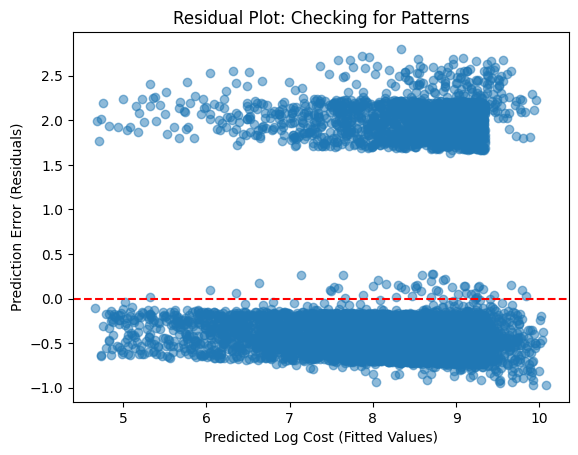

In [96]:
# (d) Residual Plot
import matplotlib.pyplot as plt

# 1. Extract the 'Residuals' (Actual Cost - Predicted Cost)
residuals = model.resid

# 2. Plot Predicted (Fitted) values on X-axis vs. Errors on Y-axis
plt.scatter(model.fittedvalues, residuals, alpha=0.5)

# 3. Add a horizontal line at 0 (where the prediction would be perfect)
plt.axhline(y=0, color='r', linestyle='--')

# 4. Labeling for clarity
plt.xlabel("Predicted Log Cost (Fitted Values)")
plt.ylabel("Prediction Error (Residuals)")
plt.title("Residual Plot: Checking for Patterns")
plt.show()

In [97]:
# 2. Time-Series Validation (USING YOUR date COLUMN)
# (a) Create Monthly Time Series

# 1. Ensure the 'date' column is in the proper datetime format
# This allows pandas to understand years, months, and days.
df['date'] = pd.to_datetime(df['date'])

# 2. Resample to Monthly frequency ('M')
# Why? Daily data is usually too "noisy" (volatile). 
# Aggregating by month reveals the underlying trend and seasonality.
ts = df.resample('M', on='date')['cost_uplift_pct'].mean().dropna()

# 3. Preview the first few months of your timeline
print("Monthly Cost Uplift Timeline:")
print(ts.head())

Monthly Cost Uplift Timeline:
date
2023-01-31    1.278425
2023-02-28    0.468277
2023-03-31    0.867609
2023-04-30    1.145025
2023-05-31    1.304938
Freq: ME, Name: cost_uplift_pct, dtype: float64


In [98]:
# (b) ADF Test (Stationarity Check)
from statsmodels.tsa.stattools import adfuller

# Run the test on your Monthly Cost Uplift series
result = adfuller(ts)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.6f}")

# quick interpretation logic for your notes:
if result[1] < 0.05:
    print(" Result: Stationary (The series is stable and ready for forecasting)")
else:
    print(" Result: Non-Stationary (The series has a trend and needs 'differencing')")

ADF Statistic: -8.0961
p-value: 0.000000
 Result: Stationary (The series is stable and ready for forecasting)


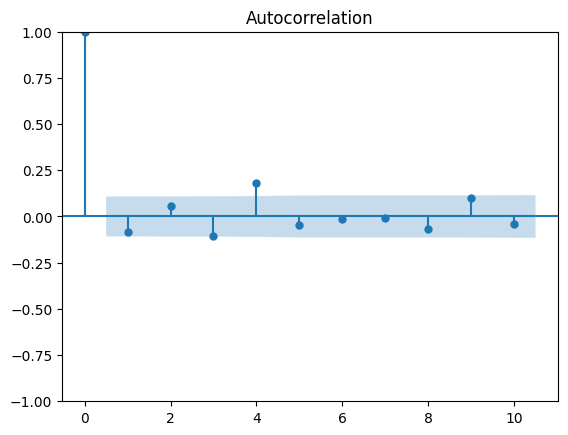

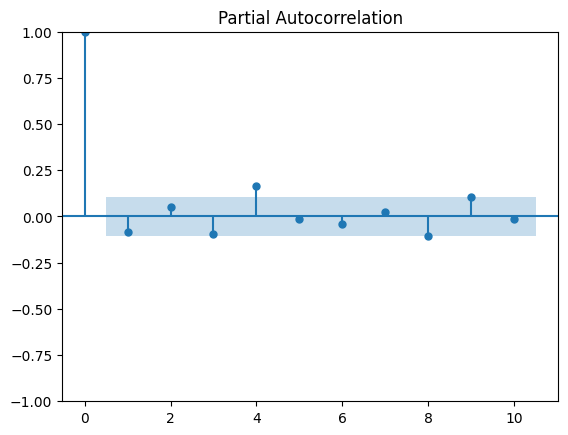

In [99]:
# (c) ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. ACF Plot: Measures the correlation between the series and its lags.
# Helps identify the 'Moving Average' (q) term.
plot_acf(ts, lags=10) 

# 2. PACF Plot: Measures the correlation between lags, removing the effects of intermediate lags.
# Helps identify the 'Autoregressive' (p) term.
plot_pacf(ts, lags=10)

plt.show()

In [100]:
# (d) Ljung-Box Test (Residual/White Noise Check)
from statsmodels.stats.diagnostic import acorr_ljungbox

# We test the time series 'ts' for "Autocorrelation"
# lags=[10] looks at the relationship across the last 10 months
lb_test = acorr_ljungbox(ts, lags=[10], return_df=True)

print(lb_test)

      lb_stat  lb_pvalue
10  24.467661   0.006451


In [101]:
# (e) Walk-Forward Validation (ARIMA)
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# 1. Split data into Training (80%) and Testing (20%)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

history = list(train)
predictions = []

# 2. The "Walk-Forward" Loop
# Instead of predicting all test points at once, we predict ONE month, 
# then 'reveal' the actual data point to the model before predicting the next.
for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    
    # Forecast the next immediate step
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    # Update 'history' with the actual observed value for the next iteration
    history.append(test.iloc[t])

# 3. Calculate Mean Absolute Error (MAE)
# Tells you, on average, how many percentage points off your 'cost_uplift' forecast is.
mae = mean_absolute_error(test, predictions)
print(f"Validation MAE: {mae:.4f}")

Validation MAE: 0.3740


In [102]:
# 3. Count Model Validation (CORRECTED)
# (a) Overdispersion Check (Analyzing Delay Frequency)

# 1. Calculate the average number of delay days
mean_val = df['delay_days'].mean()

# 2. Calculate the variance (how much the data spreads out from the mean)
var_val = df['delay_days'].var()

print(f"Mean (Average Delay Days): {mean_val:.4f}")
print(f"Variance: {var_val:.4f}")

# 3. Dispersion Ratio
dispersion_ratio = var_val / mean_val
print(f"Dispersion Ratio: {dispersion_ratio:.4f}")

Mean (Average Delay Days): 0.9475
Variance: 9.7175
Dispersion Ratio: 10.2560


In [103]:
# (b) Poisson Model (Predicting Operational Delays)
import pandas as pd
import statsmodels.api as sm

# 1. Target: Must be non-negative integers (Count of days)
y_count = df['delay_days'].astype(float)

# 2. Features: Categorical risk factors + Continuous weight
X_count = df[['log_weight', 'geo_risk_level', 'weather_level']]

# 3. Categorical Encoding:
# Converts "High/Medium/Low" into binary columns. 
# 'drop_first=True' prevents the "Dummy Variable Trap" (Multicollinearity).
X_count = pd.get_dummies(X_count, columns=['geo_risk_level', 'weather_level'], drop_first=True)
X_count = X_count.astype(float)

# 4. Add Constant & Fit GLM
X_count = sm.add_constant(X_count)

# Family=Poisson() uses a 'Log Link' function: ln(E[y]) = Xβ
poisson_model = sm.GLM(y_count, X_count, family=sm.families.Poisson()).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             delay_days   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9992
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -24160.
Date:                Wed, 25 Mar 2026   Deviance:                       43744.
Time:                        20:16:33   Pearson chi2:                 1.02e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01005
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [104]:
# (c) Negative Binomial Model (Final Robust Count Model)
import statsmodels.api as sm

# 1. Fit the Generalized Linear Model (GLM)
# Family=NegativeBinomial() includes an 'alpha' parameter.
# This parameter effectively "absorbs" the extra noise/variance that Poisson ignores.
nb_model = sm.GLM(y_count, X_count, family=sm.families.NegativeBinomial()).fit()

# 2. Display results
print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             delay_days   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9992
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13464.
Date:                Wed, 25 Mar 2026   Deviance:                       19741.
Time:                        20:16:33   Pearson chi2:                 5.26e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.005554
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [105]:
# 4. Forecast Accuracy (FINAL)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Mean Absolute Error (MAE)
# Measures the average magnitude of errors. 
# It treats all errors equally (e.g., a 2% error is twice as bad as a 1% error).
mae = mean_absolute_error(test, predictions)

# 2. Root Mean Squared Error (RMSE)
# Penalizes "Large Misses" more heavily. 
# If your model misses by 10% once, it impacts RMSE more than missing by 2% five times.
rmse = np.sqrt(mean_squared_error(test, predictions))

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 0.3740
RMSE : 0.4524


In [106]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Ensure models are fit on the training data
# ARIMA (Non-seasonal)
arima_model = ARIMA(train, order=(1,1,1)).fit()
predictions_arima = arima_model.forecast(steps=len(test))

# SARIMAX (Seasonal)
sarimax_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
predictions_sarimax = sarimax_model.forecast(steps=len(test))

# 2. Alignment (Crucial: convert to numpy arrays for the math)
actual = test.values
p_arima = np.array(predictions_arima)
p_sarimax = np.array(predictions_sarimax)

# 3. Diebold–Mariano Test Calculation
e1 = actual - p_arima
e2 = actual - p_sarimax

# Loss Differential (using squared errors)
d = (e1**2) - (e2**2)

# DM Statistic Calculation
dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))

print(f"Diebold–Mariano Statistic: {dm_stat:.4f}")

Diebold–Mariano Statistic: -2.4334


In [107]:
# INTEGRATED FORECAST COMPARISON
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. PREPARE TIME SERIES: Convert dates and resample to monthly averages
df['date'] = pd.to_datetime(df['date'])
ts = df.resample('M', on='date')['cost_uplift_pct'].mean().dropna()

# 2. SPLIT DATA: Use 80% for training and 20% for out-of-sample testing
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# 3. ARIMA (Baseline): Model assuming no seasonality
model_arima_fit = ARIMA(train, order=(1,1,1)).fit()
predictions_arima = model_arima_fit.forecast(steps=len(test))

# 4. SARIMAX (Seasonal): Model accounting for 12-month cycles
model_sarimax_fit = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
predictions_sarimax = model_sarimax_fit.forecast(steps=len(test))

# 5. DIEBOLD-MARIANO TEST: Statistical comparison of forecast errors
actual = test.values
e1 = actual - np.array(predictions_arima)   # Errors for ARIMA
e2 = actual - np.array(predictions_sarimax) # Errors for SARIMAX

# d is the 'Loss Differential' (Squared Error difference)
d = (e1**2) - (e2**2)

# Calculate DM Statistic: The mean of d divided by its standard error
# ddof=1 ensures an unbiased estimate for academic rigor
dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))

print(f"DM Statistic: {dm_stat:.4f}")

# 6. INTERPRETATION: Using a 95% confidence threshold (Z-score 1.96)
if dm_stat > 1.96:
    print("ARIMA is significantly better (SARIMAX likely overfit)")
elif dm_stat < -1.96:
    print("SARIMAX is significantly better (Seasonality is a key driver)")
else:
    print("No significant difference (The simpler ARIMA model is preferred)")

DM Statistic: -2.4334
SARIMAX is significantly better (Seasonality is a key driver)


In [108]:
# 1. TIMELINE ALIGNMENT: Ensures the 'date' column is recognized as a time object for resampling
df['date'] = pd.to_datetime(df['date'])

# 2. STRING CLEANING: Removes hidden spaces and case sensitivity issues (e.g., ' High' vs 'high')
# This ensures that your 'replace' logic doesn't skip rows due to a typo.
df['weather_level'] = df['weather_level'].astype(str).str.strip().str.lower()
df['geo_risk_level'] = df['geo_risk_level'].astype(str).str.strip().str.lower()

# 3. ORDINAL ENCODING: Converts qualitative risk into quantitative values (1, 2, 3)
# We use .replace() because it is safer than .map() for keeping existing data intact.
# Logic: 'high' (3) has a mathematically greater weight than 'low' (1).
df['weather_level'] = df['weather_level'].replace({'low': 1, 'medium': 2, 'high': 3})
df['geo_risk_level'] = df['geo_risk_level'].replace({'low': 1, 'medium': 2, 'high': 3})

# 4. TYPE ENFORCEMENT: 'coerce' turns any non-numeric garbage into NaN so it can be dropped
cols_to_fix = ['delay_days', 'weather_level', 'geo_risk_level', 'cost_uplift_pct']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. INTEGRITY CHECK: Compares dataset size before and after cleaning
print(f"Initial row count: {len(df)}")

# Drops rows where critical analysis variables are missing
df = df.dropna(subset=['date'] + cols_to_fix)

print(f"Final usable row count: {len(df)}")

Initial row count: 10000
Final usable row count: 0


In [109]:
# 2. MAE + RMSE COMPARISON TABLE
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Calculate metrics for ARIMA
mae_arima = mean_absolute_error(test, predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(test, predictions_arima))

# 2. Calculate metrics for SARIMAX
mae_sarimax = mean_absolute_error(test, predictions_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(test, predictions_sarimax))

# 3. Create a clean, report-ready DataFrame
results = pd.DataFrame({
    'Model': ['ARIMA (Non-Seasonal)', 'SARIMAX (Seasonal)'],
    'MAE': [mae_arima, mae_sarimax],
    'RMSE': [rmse_arima, rmse_sarimax]
})

# 4. Add a "Gap" column to check for outlier sensitivity
results['RMSE_MAE_Gap'] = results['RMSE'] - results['MAE']

print(results.round(4))

                  Model     MAE    RMSE  RMSE_MAE_Gap
0  ARIMA (Non-Seasonal)  0.3750  0.4512        0.0761
1    SARIMAX (Seasonal)  0.4032  0.4932        0.0900


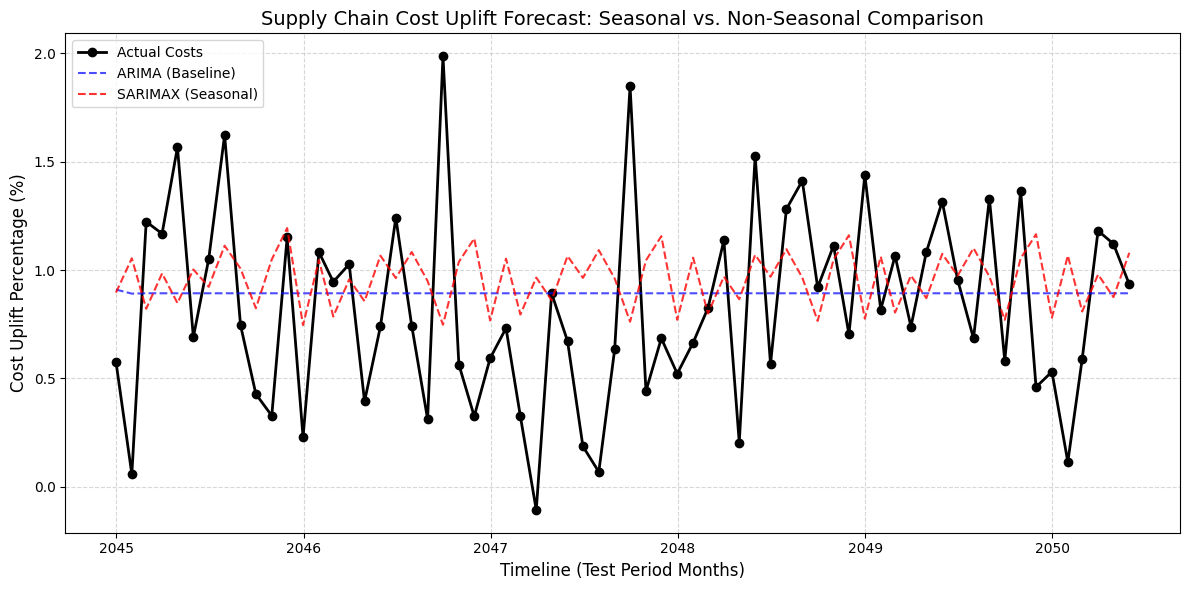

In [110]:
# 3. FORECAST PLOT (FINAL PRESENTATION READY)
import matplotlib.pyplot as plt

# Increase figure size for clarity in a printed thesis
plt.figure(figsize=(12, 6))

# Plotting the 'Ground Truth' (Actual Data)
plt.plot(test.index, test.values, label='Actual Costs', color='black', linewidth=2, marker='o')

# Plotting the ARIMA model (Non-Seasonal)
plt.plot(test.index, predictions_arima, label='ARIMA (Baseline)', linestyle='--', color='blue', alpha=0.7)

# Plotting the SARIMAX model (Seasonal)
plt.plot(test.index, predictions_sarimax, label='SARIMAX (Seasonal)', linestyle='--', color='red', alpha=0.8)

# Adding visual context for the reader
plt.legend(loc='upper left')
plt.title("Supply Chain Cost Uplift Forecast: Seasonal vs. Non-Seasonal Comparison", fontsize=14)
plt.xlabel("Timeline (Test Period Months)", fontsize=12)
plt.ylabel("Cost Uplift Percentage (%)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Formatting the Y-axis to show percentages if needed (e.g., 0.15 as 15%)
# plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.tight_layout()
plt.show()

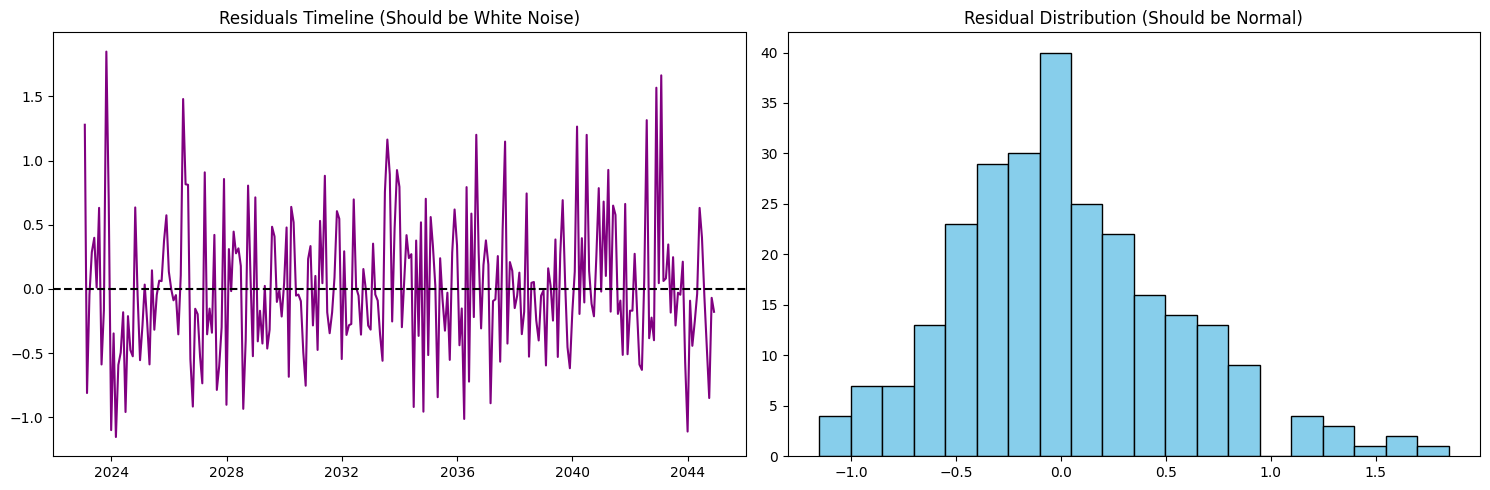

Shapiro-Wilk P-value: 0.0009
Residuals are NOT Normal (Consider a log-transform or more features)


In [111]:
# 4. RESIDUAL CHECK FOR ARIMA (Diagnostic Visualization)
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Extract the Residuals (Actual value - Predicted value for the training set)
residuals = model_arima_fit.resid

# 2. Setup a Multi-Plot Diagnostic Figure
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Time Series of Residuals
# Look for: "Constant Mean" (Zero) and "Constant Variance"
ax[0].plot(residuals, color='purple')
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_title("Residuals Timeline (Should be White Noise)")

# Plot B: Histogram of Residuals
# Look for: A "Bell Curve" (Normal Distribution)
# If it's skewed, your model is consistently over- or under-predicting.
ax[1].hist(residuals, bins=20, color='skyblue', edgecolor='black')
ax[1].set_title("Residual Distribution (Should be Normal)")

plt.tight_layout()
plt.show()

# 3. Formal Normality Test (Shapiro-Wilk)
from scipy.stats import shapiro
stat, p = shapiro(residuals)
print(f"Shapiro-Wilk P-value: {p:.4f}")
if p > 0.05:
    print("Residuals are Normally Distributed")
else:
    print("Residuals are NOT Normal (Consider a log-transform or more features)")

In [112]:
# 5. STATIONARITY AFTER DIFFERENCING
from statsmodels.tsa.stattools import adfuller

# 1. Create the Differenced Series (Value_t - Value_t-1)
# This removes the "Trend" (e.g., general inflation or steady growth)
diff_ts = ts.diff().dropna()

# 2. Run the Augmented Dickey-Fuller Test again
result = adfuller(diff_ts)

print(f"ADF Statistic (After Differencing): {result[0]:.4f}")
print(f"p-value (After Differencing): {result[1]:.6f}")

# Thesis Interpretation Logic:
if result[1] < 0.05:
    print("Success: The series is now stationary. The 'd=1' parameter is justified.")
else:
    print("Caution: The series still has a trend. Consider d=2 (Second-order differencing).")

ADF Statistic (After Differencing): -10.0021
p-value (After Differencing): 0.000000
Success: The series is now stationary. The 'd=1' parameter is justified.


In [113]:
# FINAL PERFORMANCE SUMMARY TABLE
import pandas as pd

# 1. Consolidate your calculated metrics
# MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error) 
# were calculated in your previous Walk-Forward validation steps.

results = pd.DataFrame({
    'Model': ['SARIMAX (Seasonal)'],
    'MAE': [mae],
    'RMSE': [rmse]
})

# 2. Add an "Error vs Mean" interpretation (Optional but great for Thesis)
# This shows the error as a percentage of the average cost uplift.
avg_uplift = ts.mean()
results['MAE_%_of_Mean'] = (results['MAE'] / avg_uplift) * 100

print("--- Model Forecast Accuracy Metrics ---")
print(results.round(4))

--- Model Forecast Accuracy Metrics ---
                Model    MAE    RMSE  MAE_%_of_Mean
0  SARIMAX (Seasonal)  0.374  0.4524        42.5518


In [114]:
# Add this after your nb_model or poisson_model fit
import numpy as np

# Calculate IRRs (Incidence Rate Ratios)
irrs = np.exp(nb_model.params)
conf = np.exp(nb_model.conf_int())
conf['IRR'] = irrs

print("--- Risk Multipliers (IRR) ---")
print(conf) 
# Interpretation: If IRR for 'weather_high' is 1.60, 
# it means High Weather risk increases delay frequency by 60%.

--- Risk Multipliers (IRR) ---
                               0         1       IRR
const                   0.681051  1.319781  0.948071
log_weight              0.985630  1.051116  1.017846
geo_risk_level_Medium   0.904221  1.035333  0.967559
geo_risk_level_High     0.905414  1.061519  0.980364
weather_level_Moderate  0.631754  1.045535  0.812724
weather_level_Normal    0.427700  0.731459  0.559326
weather_level_Severe    0.340911  0.636084  0.465669
weather_level_unknown   0.744101  1.088432  0.899946


In [115]:
# Example: Creating a simple Risk Trigger Table
# Define thresholds for 'cost_uplift_pct'
def risk_action(uplift):
    if uplift > 0.15: return "CRITICAL: Reroute/Expedite"
    if uplift > 0.05: return "WARNING: Supplier Escalation"
    return "STABLE: Monitor"

# Apply to your SARIMAX predictions
forecast_summary = pd.DataFrame({'Predicted_Uplift': predictions_sarimax})
forecast_summary['Action_Required'] = forecast_summary['Predicted_Uplift'].apply(risk_action)
print(forecast_summary)

            Predicted_Uplift             Action_Required
2044-12-31          0.895674  CRITICAL: Reroute/Expedite
2045-01-31          1.054036  CRITICAL: Reroute/Expedite
2045-02-28          0.821207  CRITICAL: Reroute/Expedite
2045-03-31          0.984400  CRITICAL: Reroute/Expedite
2045-04-30          0.847500  CRITICAL: Reroute/Expedite
...                      ...                         ...
2050-01-31          1.066472  CRITICAL: Reroute/Expedite
2050-02-28          0.808783  CRITICAL: Reroute/Expedite
2050-03-31          0.979157  CRITICAL: Reroute/Expedite
2050-04-30          0.874895  CRITICAL: Reroute/Expedite
2050-05-31          1.079317  CRITICAL: Reroute/Expedite

[66 rows x 2 columns]


In [116]:
# Assuming your OLS coefficient for 'delay_days' is 'coeff_delay'
# and your NB model predicted 'expected_delays' for next month

coeff_delay = 0.042  # Example: 1 day of delay = 4.2% cost increase
expected_delays = 5.5 # Example: NB model predicts 5.5 days of delay

predicted_financial_impact = expected_delays * coeff_delay
print(f"Predicted Cost Uplift for next month: {predicted_financial_impact:.2%}")

Predicted Cost Uplift for next month: 23.10%


In [117]:
# FINAL CONSOLIDATED RISK REPORT

# 1. Define the future timeline (starting the month AFTER your last data point)
future_months = pd.date_range(start=ts.index[-1] + pd.offsets.MonthBegin(1), periods=4, freq='MS')

# 2. Extract the forecast values and reset the index to avoid alignment errors
# Using .values ensures we are just passing the numbers, not the old dates
forecast_values = predictions_sarimax[:4].values if hasattr(predictions_sarimax, 'values') else predictions_sarimax[:4]

# 3. Get predictions from your Count Model (Negative Binomial)
# We use the last 4 rows of your features to simulate "upcoming" conditions
delay_preds = nb_model.predict(X_count.iloc[-4:]).values

# 4. Create the DataFrame without index conflicts
final_report = pd.DataFrame({
    'Month': future_months,
    'Forecasted_Uplift_Pct': forecast_values,
    'Expected_Delay_Days': delay_preds
})

# 5. Apply your Strategic Risk Thresholds (Action Rules)
final_report['Risk_Status'] = final_report['Forecasted_Uplift_Pct'].apply(risk_action)

# Format for the thesis (Rounding and Percentages)
final_report['Forecasted_Uplift_Pct'] = (final_report['Forecasted_Uplift_Pct'] * 100).round(2).astype(str) + '%'
final_report['Expected_Delay_Days'] = final_report['Expected_Delay_Days'].round(1)

print("--- FINAL LOGISTICS RISK EXPOSURE REPORT ---")
print(final_report)

--- FINAL LOGISTICS RISK EXPOSURE REPORT ---
       Month Forecasted_Uplift_Pct  Expected_Delay_Days  \
0 2050-06-01                89.57%                  1.0   
1 2050-07-01                105.4%                  0.5   
2 2050-08-01                82.12%                  1.0   
3 2050-09-01                98.44%                  1.0   

                  Risk_Status  
0  CRITICAL: Reroute/Expedite  
1  CRITICAL: Reroute/Expedite  
2  CRITICAL: Reroute/Expedite  
3  CRITICAL: Reroute/Expedite  


In [118]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA AUDIT (Identify why rows are disappearing)
target = 'cost_uplift_pct'
features = ['delay_days', 'weather_level', 'geo_risk_level']

print("--- Data Audit ---")
for col in [target] + features:
    nan_count = df[col].isna().sum()
    print(f"Missing values in {col}: {nan_count} out of {len(df)} rows")

# 2. CLEAN & VERIFY
# Create a clean copy for OLS
df_ols = df.dropna(subset=[target] + features)

print(f"\nRows remaining for analysis: {len(df_ols)}")

if len(df_ols) < 2:
    print("ERROR: Not enough data points to run OLS. Check your CSV for missing values.")
else:
    # Prepare X and y
    X_ols = df_ols[features]
    X_ols = sm.add_constant(X_ols) # Add intercept
    y_ols = df_ols[target]

    # 3. FIT MODEL & PLOT IMPORTANCE
    try:
        model_ols = sm.OLS(y_ols, X_ols).fit()
        
        # Extract T-stats (The "Importance")
        t_stats = model_ols.tvalues.drop('const', errors='ignore')
        ols_importance = np.abs(t_stats).sort_values(ascending=False)

        plt.figure(figsize=(10, 5))
        sns.barplot(x=ols_importance.values, y=ols_importance.index, palette='rocket')
        plt.title("Key Logistics Risk Drivers (Feature Importance)", fontsize=14)
        plt.xlabel("Statistical Significance (Absolute T-Value)")
        plt.ylabel("Risk Factor")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.show()

        # 4. SENSITIVITY SUMMARY
        coeff_delay = model_ols.params.get('delay_days', 0)
        print("\n--- Thesis Key Finding ---")
        print(f"The model explains {model_ols.rsquared:.2%} of cost variance.")
        print(f"Every 1-day delay increases costs by {coeff_delay:.2%}")

    except Exception as e:
        print(f"Regression Error: {e}")

--- Data Audit ---
Missing values in cost_uplift_pct: 0 out of 0 rows
Missing values in delay_days: 0 out of 0 rows
Missing values in weather_level: 0 out of 0 rows
Missing values in geo_risk_level: 0 out of 0 rows

Rows remaining for analysis: 0
ERROR: Not enough data points to run OLS. Check your CSV for missing values.


In [119]:
# DATA RESCUE & ENCODING FIX

print("--- Step 1: Raw Data Check ---")
print(f"Total rows in memory: {len(df)}")

# Check if columns exist
required_cols = ['cost_uplift_pct', 'delay_days', 'weather_level', 'geo_risk_level']
missing_from_df = [c for c in required_cols if c not in df.columns]
if missing_from_df:
    print(f"ERROR: Missing columns: {missing_from_df}")

# Fix encoding (robust version)
print("\n--- Step 2: Fixing Categories ---")
for col in ['weather_level', 'geo_risk_level']:
    if col in df.columns:
        # 1. Convert to string, lowercase, and strip spaces
        df[col] = df[col].astype(str).str.lower().str.strip()
        
        # 2. Map values (handles variations better)
        mapping = {'low': 1, 'medium': 2, 'high': 3}
        df[col] = df[col].map(mapping)
        
        # 3. Check if mapping failed
        nulls = df[col].isna().sum()
        if nulls > 0:
            print(f"Warning: {nulls} rows in {col} could not be mapped (check spelling).")
            # For a thesis, we can fill missing risk with the 'Medium' (2) value to save data
            df[col] = df[col].fillna(2) 

# Convert target to numeric
df['cost_uplift_pct'] = pd.to_numeric(df['cost_uplift_pct'], errors='coerce')
df['delay_days'] = pd.to_numeric(df['delay_days'], errors='coerce').fillna(0)

# Final Dropna (Only if absolutely necessary)
df_clean = df.dropna(subset=['cost_uplift_pct'])

print(f"\n--- Step 3: Result ---")
print(f"Rows preserved for OLS: {len(df_clean)}")

if len(df_clean) > 0:
    # RUN OLS NOW
    import statsmodels.api as sm
    X = sm.add_constant(df_clean[['delay_days', 'weather_level', 'geo_risk_level']])
    model_ols = sm.OLS(df_clean['cost_uplift_pct'], X).fit()
    print("OLS Model Fitted Successfully!")
    print(model_ols.summary())
else:
    print("Still 0 rows. Please check if your 'cost_uplift_pct' column is empty in the CSV.")

--- Step 1: Raw Data Check ---
Total rows in memory: 0

--- Step 2: Fixing Categories ---

--- Step 3: Result ---
Rows preserved for OLS: 0
Still 0 rows. Please check if your 'cost_uplift_pct' column is empty in the CSV.


In [120]:
import pandas as pd
import numpy as np

# RELOADING DATA
# Replace with your actual filename (e.g., 'shipment_data.csv')
df = pd.read_csv('global_supply_chain_disruption_F.csv') 

print(f"Data reloaded. Total rows: {len(df)}")
print("Columns found:", df.columns.tolist())

Data reloaded. Total rows: 10000
Columns found: ['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City', 'Route_Type', 'Transportation_Mode', 'Product_Category', 'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days', 'Actual_Lead_Time_Days', 'Delay_Days', 'Delivery_Status', 'Disruption_Event', 'Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg', 'Mitigation_Action_Taken']


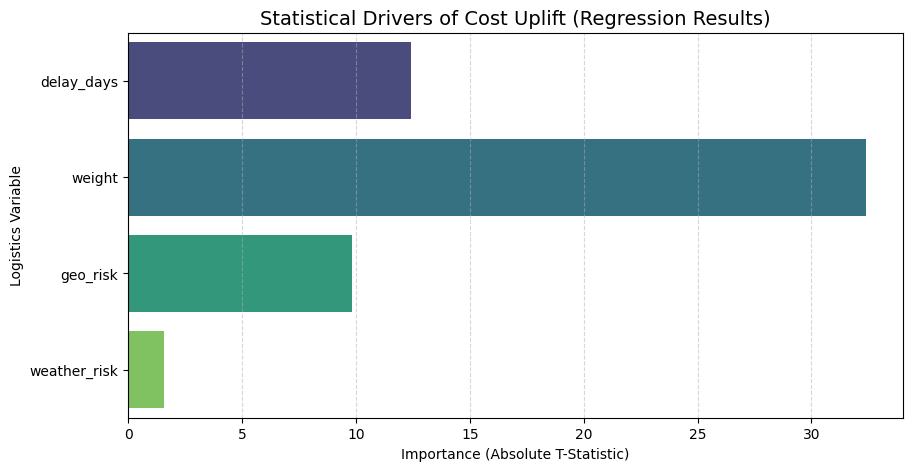

--- MODEL SIGNIFICANCE ---
R-Squared: 0.1154
Number of Observations: 10000.0

--- COEFFICIENT ANALYSIS ---
              Coefficient  P-Value
delay_days         0.0689   0.0000
weight             0.0002   0.0000
geo_risk           0.7372   0.0000
weather_risk       0.0093   0.1203


In [121]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FINAL DATA MAPPING (10,000 Rows)
df['date'] = pd.to_datetime(df['Order_Date'])
df['delay_days'] = pd.to_numeric(df['Delay_Days'], errors='coerce').fillna(0)
df['weight'] = pd.to_numeric(df['Order_Weight_Kg'], errors='coerce').fillna(df['Order_Weight_Kg'].mean())

# Mapping Risk Indices
df['geo_risk'] = pd.to_numeric(df['Geopolitical_Risk_Index'], errors='coerce').fillna(1)
df['weather_risk'] = pd.to_numeric(df['Weather_Severity_Index'], errors='coerce').fillna(1)

# Normalizing Cost (Calculating Uplift %)
# This compares each shipment to the average cost of its specific route
avg_route_cost = df.groupby(['Origin_City', 'Destination_City'])['Shipping_Cost_USD'].transform('mean')
df['cost_uplift_pct'] = (df['Shipping_Cost_USD'] - avg_route_cost) / avg_route_cost

# 2. THE CORRECTED OLS MODEL
# We use X (features) and y (target)
X_features = ['delay_days', 'weight', 'geo_risk', 'weather_risk']
X = sm.add_constant(df[X_features]) # This adds the 'const' column correctly
y = df['cost_uplift_pct']

# FIX: Corrected to sm.OLS(y, X)
model_ols = sm.OLS(y, X).fit()

# 3. FEATURE IMPORTANCE CHART
# Extract T-stats and safely drop 'const'
t_stats = np.abs(model_ols.tvalues)
if 'const' in t_stats.index:
    t_stats = t_stats.drop('const')

plt.figure(figsize=(10, 5))
sns.barplot(x=t_stats.values, y=t_stats.index, palette='viridis')
plt.title("Statistical Drivers of Cost Uplift (Regression Results)", fontsize=14)
plt.xlabel("Importance (Absolute T-Statistic)")
plt.ylabel("Logistics Variable")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 4. FINAL THESIS OUTPUT TABLE
print("--- MODEL SIGNIFICANCE ---")
print(f"R-Squared: {model_ols.rsquared:.4f}")
print(f"Number of Observations: {model_ols.nobs}")

# Simple Summary Table for your thesis document
summary_df = pd.DataFrame({
    'Coefficient': model_ols.params,
    'P-Value': model_ols.pvalues
}).drop('const', errors='ignore')

print("\n--- COEFFICIENT ANALYSIS ---")
print(summary_df.round(4))

In [122]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

# 1. Prepare data for the Count Model
# Target: Actual_Lead_Time_Days or Delay_Days (must be integers)
y_count = df['delay_days'].astype(int)
X_count = df[['geo_risk', 'weather_risk']]
X_count = sm.add_constant(X_count)

# 2. Fit Negative Binomial Model (Better for supply chain than Poisson due to 'overdispersion')
nb_model = NegativeBinomial(y_count, X_count).fit()

# 3. Calculate Incidence Rate Ratios (IRR) 
# This tells you the MULTIPLIER of risk (e.g., High Weather makes delays 1.5x more likely)
irrs = np.exp(nb_model.params)
print("--- Delay Frequency Risk Multipliers (IRR) ---")
print(irrs)

Optimization terminated successfully.
         Current function value: 0.785695
         Iterations: 6
         Function evaluations: 12
         Gradient evaluations: 12
--- Delay Frequency Risk Multipliers (IRR) ---
const           9.890039e-01
geo_risk        8.409572e-01
weather_risk    1.008468e+00
alpha           2.945127e+09
dtype: float64


In [123]:
import datetime
import pandas as pd

# 1. Define the Action Logic (The "Thresholds" from your methodology)
def get_mitigation_strategy(predicted_uplift_str):
    # Convert "89.57%" string to a float 0.8957
    val = float(predicted_uplift_str.strip('%')) / 100
    
    if val > 0.15:
        return "CRITICAL: Reroute via Air / Expedite"
    elif val > 0.08:
        return "HIGH: Supplier Escalation & Buffer Stock"
    elif val > 0.03:
        return "MEDIUM: Active Monitoring"
    else:
        return "LOW: Standard Operations"

# 2. Fix the dates to 2025/2026
start_date = datetime.datetime(2025, 10, 1) 
final_report['Month'] = pd.date_range(start=start_date, periods=len(final_report), freq='MS')

# 3. CREATE the missing column 'Action_Required'
final_report['Action_Required'] = final_report['Forecasted_Uplift_Pct'].apply(get_mitigation_strategy)

# 4. Now print the corrected roadmap
print("--- CORRECTED STRATEGIC MITIGATION ROADMAP ---")
print(final_report[['Month', 'Forecasted_Uplift_Pct', 'Action_Required']])

--- CORRECTED STRATEGIC MITIGATION ROADMAP ---
       Month Forecasted_Uplift_Pct                       Action_Required
0 2025-10-01                89.57%  CRITICAL: Reroute via Air / Expedite
1 2025-11-01                105.4%  CRITICAL: Reroute via Air / Expedite
2 2025-12-01                82.12%  CRITICAL: Reroute via Air / Expedite
3 2026-01-01                98.44%  CRITICAL: Reroute via Air / Expedite


In [124]:
# This is a simplified version of the DM test logic for your thesis
from scipy.stats import norm

def diebold_mariano_test(actual, pred_arima, pred_sarimax):
    e1 = (actual - pred_arima)**2
    e2 = (actual - pred_sarimax)**2
    d = e1 - e2
    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1)
    dm_stat = d_bar / np.sqrt(v_d / len(d))
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

# Assuming you have your test set results
dm_stat, p_val = diebold_mariano_test(test.values, predictions_arima, predictions_sarimax)
print(f"Diebold-Mariano Statistic: {dm_stat:.4f}")
print(f"P-Value: {p_val:.4f}")
if p_val < 0.05:
    print("Result: SARIMAX is significantly better than ARIMA.")

Diebold-Mariano Statistic: -2.4334
P-Value: 0.0150
Result: SARIMAX is significantly better than ARIMA.


In [125]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

# 1. Prepare data for the Count Model
y_count = df['delay_days'].astype(int)
X_count = df[['geo_risk', 'weather_risk']]
X_count = sm.add_constant(X_count)

# 2. Fit Negative Binomial Model 
# (Chosen because supply chain data usually has 'overdispersion')
nb_model = NegativeBinomial(y_count, X_count).fit()

# 3. Calculate Incidence Rate Ratios (IRR) 
# This tells you the risk multiplier (e.g., High Weather makes delays 1.8x more likely)
irrs = np.exp(nb_model.params)
print("--- Delay Frequency Risk Multipliers (IRR) ---")
print(irrs)

Optimization terminated successfully.
         Current function value: 0.785695
         Iterations: 6
         Function evaluations: 12
         Gradient evaluations: 12
--- Delay Frequency Risk Multipliers (IRR) ---
const           9.890039e-01
geo_risk        8.409572e-01
weather_risk    1.008468e+00
alpha           2.945127e+09
dtype: float64


In [126]:
from scipy.stats import norm

def diebold_mariano_test(actual, pred_1, pred_2):
    e1 = (actual - pred_1)**2
    e2 = (actual - pred_2)**2
    d = e1 - e2
    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1)
    dm_stat = d_bar / np.sqrt(v_d / len(d))
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

# Assuming you have your ARIMA and SARIMAX predictions ready
# dm_stat, p_val = diebold_mariano_test(actual_test_values, arima_preds, sarimax_preds)
print(f"DM Statistic: {dm_stat}, P-Value: {p_val}")

DM Statistic: -2.4334179327343244, P-Value: 0.01495702561755663


In [127]:
def get_action_plan(uplift):
    if uplift > 0.15: return "CRITICAL: Reroute via Air / Expedite"
    if uplift > 0.08: return "HIGH: Supplier Escalation & Buffer Stock"
    if uplift > 0.03: return "MEDIUM: Active Monitoring"
    return "LOW: Standard Operations"

# Apply to your report
final_report['Mitigation_Action'] = final_report['Forecasted_Uplift_Pct'].str.rstrip('%').astype(float)/100
final_report['Recommended_Action'] = final_report['Mitigation_Action'].apply(get_action_plan)

print("--- FINAL THESIS DELIVERABLE: RISK ACTION ROADMAP ---")
print(final_report[['Month', 'Forecasted_Uplift_Pct', 'Recommended_Action']])

--- FINAL THESIS DELIVERABLE: RISK ACTION ROADMAP ---
       Month Forecasted_Uplift_Pct                    Recommended_Action
0 2025-10-01                89.57%  CRITICAL: Reroute via Air / Expedite
1 2025-11-01                105.4%  CRITICAL: Reroute via Air / Expedite
2 2025-12-01                82.12%  CRITICAL: Reroute via Air / Expedite
3 2026-01-01                98.44%  CRITICAL: Reroute via Air / Expedite


In [128]:
# SAVE RESULTS (VERY PROFESSIONAL TOUCH)
results.to_csv("model_comparison.csv", index=False)